In [1]:
import os
import sys
import sklearn
import keras_tuner
import numpy as np
import collections
import seaborn as sns
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from baseline import ResnetTuner
import train_constants as c

sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("Modules"))))
import Modules.ds_loader as ds_loader

dataset_loader = ds_loader.DatasetLoader(
    xlsx_path="../Data/Internal_Dataset/Label_Map.xlsx",
    data_dir="../Data/Internal_Dataset",
)

X, y = dataset_loader.load_data()

X_train, X_temp, y_train, y_temp = sklearn.model_selection.train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

X_val, X_test, y_val, y_test = sklearn.model_selection.train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, shuffle=True
)
print(f"Class distribution of training: {collections.Counter(y_train)}")
print(f"Class distribution of validation: {collections.Counter(y_val)}")
print(f"Class distribution of test: {collections.Counter(y_test)}")
def min_max_normalize(*datasets):
    normalized_datasets = []
    for data in datasets:
        norm_data = []
        for sample in data:
            min_val = np.min(sample)
            max_val = np.max(sample)
            if max_val - min_val == 0:
                norm_sample = np.zeros_like(sample, dtype=np.float32)
            else:
                norm_sample = (sample - min_val) / (max_val - min_val)
            norm_data.append(norm_sample)
        normalized_datasets.append(np.stack(norm_data, axis=0).astype(np.float32))
    return normalized_datasets

2025-05-28 20:54:59.869475: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-28 20:54:59.883049: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748458499.896122  736395 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748458499.900346  736395 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1748458499.912270  736395 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Class distribution of training: Counter({np.int32(2): 3136, np.int32(1): 1803, np.int32(0): 1773, np.int32(3): 1758})
Class distribution of validation: Counter({np.int32(2): 563, np.int32(3): 350, np.int32(1): 342, np.int32(0): 333})
Class distribution of test: Counter({np.int32(2): 189, np.int32(1): 115, np.int32(3): 114, np.int32(0): 112})


In [2]:
tuner = keras_tuner.RandomSearch(
    ResnetTuner(),
    objective="val_accuracy",
    max_trials=100,
    overwrite=False,
    directory=c.RDIR,
    project_name=f"RES_{c.INPUT_SIZE}_{c.FILTERS}",
)

tuner.reload()

best_trials = tuner.oracle.get_best_trials(num_trials=10)

for trial in best_trials:
    print(f"Trial ID: {trial.trial_id}, Score: {trial.score}")
    print("Hyperparameters:", trial.hyperparameters.values)

I0000 00:00:1748458510.931878  736395 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1189 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Reloading Tuner from Results/RES_500_64_08/RES_500_64/tuner0.json
Trial ID: 266, Score: 0.9672544002532959
Hyperparameters: {'f_units': 32, 'p_size': 5, 'n_convolutions': 3, 'm_convolutions': 3, 'kernel_size_init': 3, 'kernel_size_res': 3, 'coefficient': 1, 'dense_units_1': 64, 'dropout_1': 0.35, 'dense_units_2': 32, 'dropout_2': 0.45, 'learning_rate': 0.0052273621802579875, 'weight_decay': 0.0003129380436471745, 'batch_size': 32}
Trial ID: 259, Score: 0.9666246771812439
Hyperparameters: {'f_units': 32, 'p_size': 5, 'n_convolutions': 3, 'm_convolutions': 3, 'kernel_size_init': 3, 'kernel_size_res': 3, 'coefficient': 1, 'dense_units_1': 64, 'dropout_1': 0.35, 'dense_units_2': 32, 'dropout_2': 0.4, 'learning_rate': 0.007193871944178236, 'weight_decay': 0.0058100991790438206, 'batch_size': 32}
Trial ID: 056, Score: 0.9653652310371399
Hyperparameters: {'f_units': 32, 'p_size': 5, 'n_convolutions': 3, 'm_convolutions': 3, 'kernel_size_init': 3, 'kernel_size_res': 3, 'coefficient': 1, 'dense

In [3]:
print(c.RDIR / f"RES_{c.INPUT_SIZE}_{c.FILTERS}" / "RESULTS.pkl")


Results/RES_500_64_08/RES_500_64/RESULTS.pkl


Loading individual model results...
✅ Loaded Model 1 results from Results/RES_500_64_08/RES_500_64/model_1.pkl
✅ Loaded Model 2 results from Results/RES_500_64_08/RES_500_64/model_2.pkl
✅ Loaded Model 3 results from Results/RES_500_64_08/RES_500_64/model_3.pkl
✅ Loaded Model 4 results from Results/RES_500_64_08/RES_500_64/model_4.pkl
✅ Loaded Model 5 results from Results/RES_500_64_08/RES_500_64/model_5.pkl
✅ Loaded Model 6 results from Results/RES_500_64_08/RES_500_64/model_6.pkl
✅ Loaded Model 7 results from Results/RES_500_64_08/RES_500_64/model_7.pkl
✅ Loaded Model 8 results from Results/RES_500_64_08/RES_500_64/model_8.pkl
✅ Loaded Model 9 results from Results/RES_500_64_08/RES_500_64/model_9.pkl
✅ Loaded Model 10 results from Results/RES_500_64_08/RES_500_64/model_10.pkl
✅ Loaded Model 11 results from Results/RES_500_64_08/RES_500_64/model_11.pkl
✅ Loaded Model 12 results from Results/RES_500_64_08/RES_500_64/model_12.pkl
✅ Loaded Model 13 results from Results/RES_500_64_08/RES_5

I0000 00:00:1748458532.313312  737137 service.cc:152] XLA service 0x7f3f240043e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748458532.313331  737137 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2025-05-28 20:55:32.330355: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1748458532.464388  737137 cuda_dnn.cc:529] Loaded cuDNN version 90501
I0000 00:00:1748458533.436943  737137 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Test - Model 1 Loss: 0.1986
Test - Model 1 Accuracy: 0.9660

Classification Report (Test - Model 1 Data):
              precision    recall  f1-score   support

           0       0.92      0.99      0.95       112
           1       0.97      0.90      0.94       115
           2       0.98      0.99      0.99       189
           3       0.98      0.96      0.97       114

    accuracy                           0.97       530
   macro avg       0.96      0.96      0.96       530
weighted avg       0.97      0.97      0.97       530

Test - Model 1 AUC: 0.9937


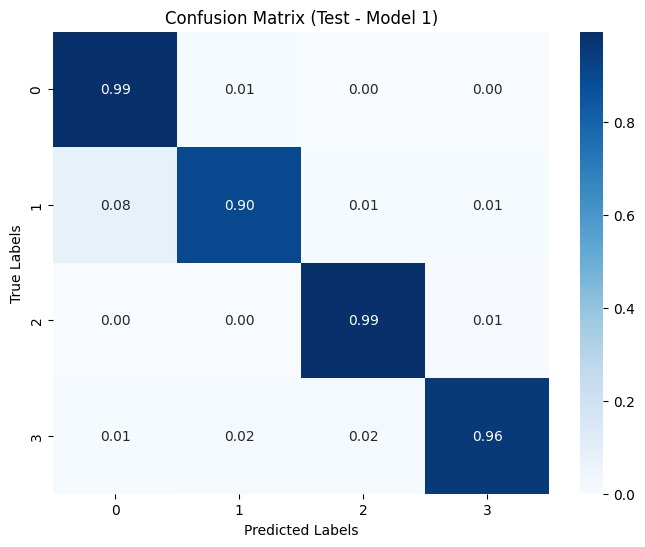


[== Evaluation on External - Model 1 Data ==]
External - Model 1 Loss: 1.2663
External - Model 1 Accuracy: 0.8064

Classification Report (External - Model 1 Data):
              precision    recall  f1-score   support

           0       0.63      0.84      0.72      1008
           1       0.35      0.94      0.51       229
           2       0.27      0.96      0.43       456
           3       0.99      0.79      0.88      9141

    accuracy                           0.81     10834
   macro avg       0.56      0.88      0.63     10834
weighted avg       0.92      0.81      0.84     10834

External - Model 1 AUC: 0.9606


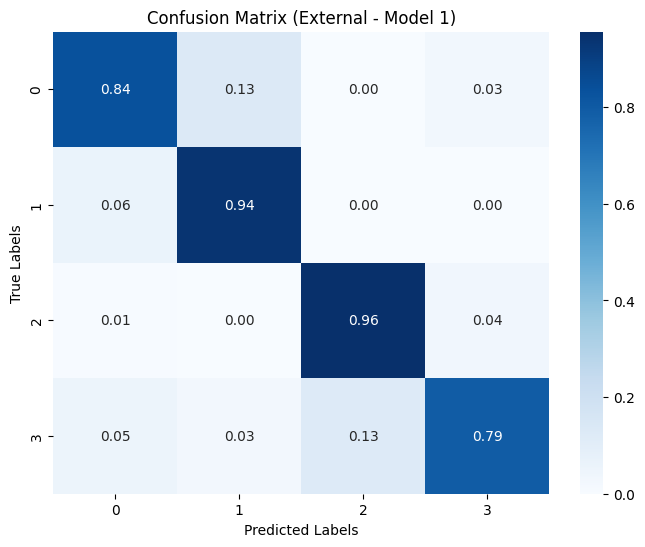

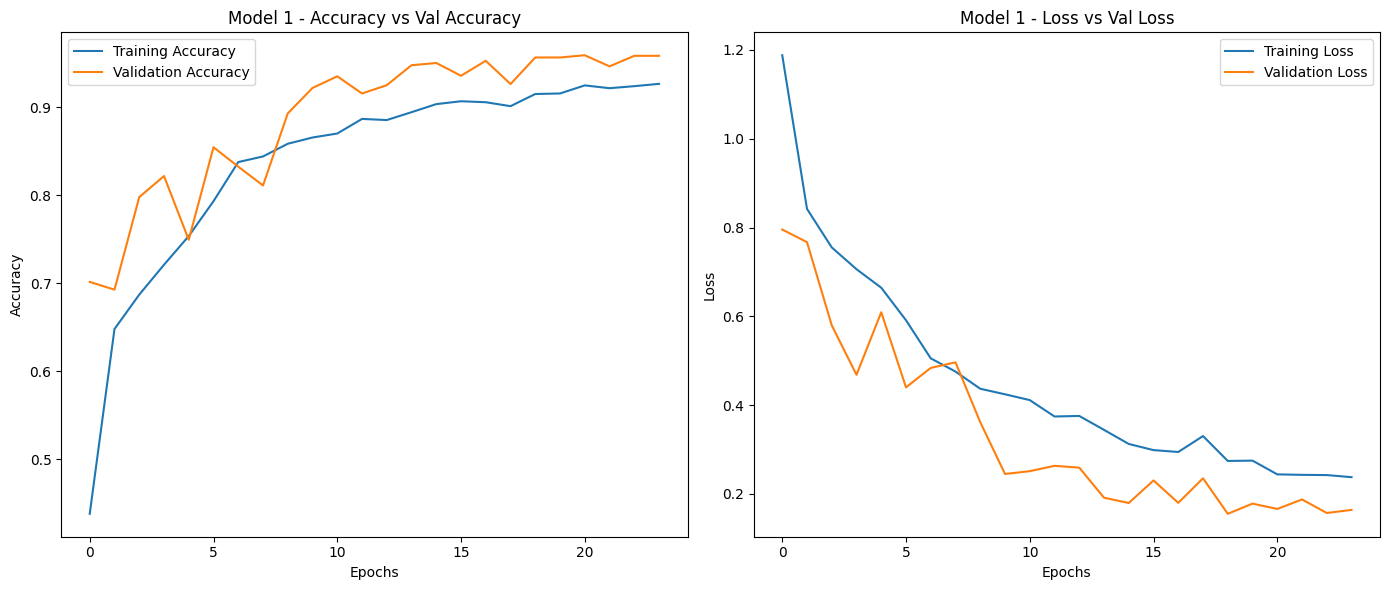


Model 1 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 2/20

Model 2 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.35
  dense_units_2: 32
  dropout_2: 0.4
  learning_rate: 0.007193871944178236
  weight_decay: 0.0058100991790438206
  batch_size: 32

=== Evaluating Model 2 ===

[== Evaluation on Test - Model 2 Data ==]
Test - Model 2 Loss: 0.1907
Test - Model 2 Accuracy: 0.9642

Classification Report (Test - Model 2 Data):
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       112
           1       0.96      0.94      0.95       115
           2       0.97      0.99      0.98       189
           3       0.98      0.93      0.95       114

    accuracy                           0.96       530
   macro avg       0.96      0.96      0.96       530
weighted avg       0.96      0.96      0.96

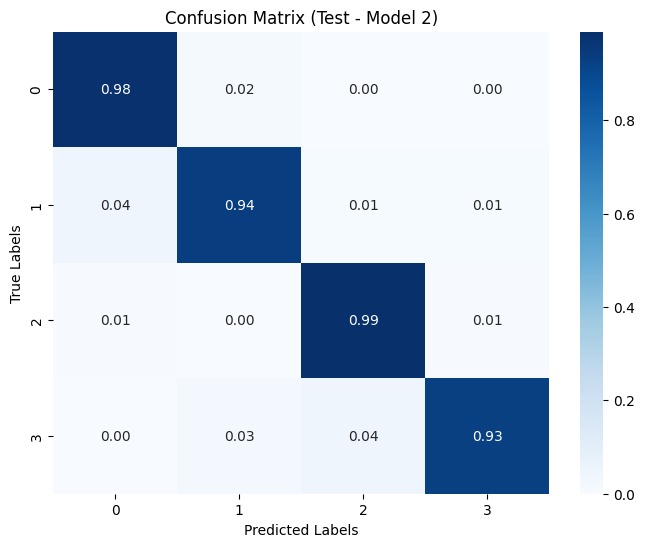


[== Evaluation on External - Model 2 Data ==]
External - Model 2 Loss: 0.9670
External - Model 2 Accuracy: 0.7736

Classification Report (External - Model 2 Data):
              precision    recall  f1-score   support

           0       0.70      0.80      0.74      1008
           1       0.26      0.99      0.41       229
           2       0.24      0.98      0.39       456
           3       1.00      0.76      0.86      9141

    accuracy                           0.77     10834
   macro avg       0.55      0.88      0.60     10834
weighted avg       0.92      0.77      0.82     10834

External - Model 2 AUC: 0.9573


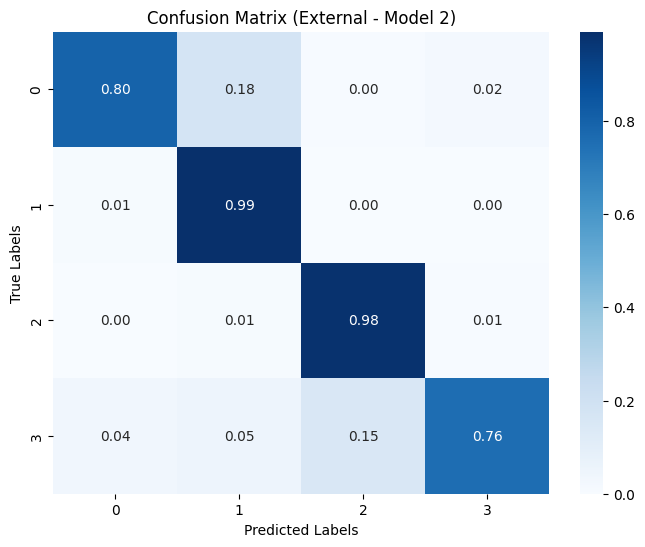

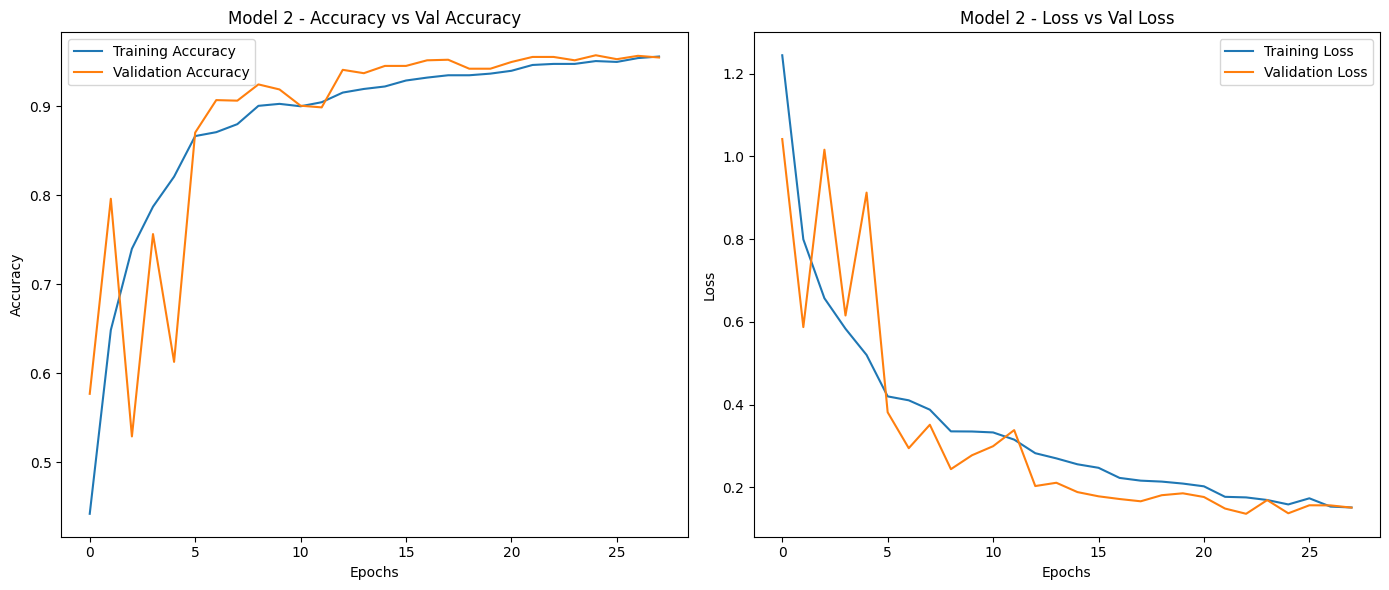


Model 2 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 3/20

Model 3 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.3
  dense_units_2: 32
  dropout_2: 0.5
  learning_rate: 0.005631726238424529
  weight_decay: 0.00400304303664308
  batch_size: 32

=== Evaluating Model 3 ===

[== Evaluation on Test - Model 3 Data ==]
Test - Model 3 Loss: 0.3822
Test - Model 3 Accuracy: 0.9528

Classification Report (Test - Model 3 Data):
              precision    recall  f1-score   support

           0       0.92      0.97      0.95       112
           1       0.95      0.90      0.92       115
           2       0.97      0.98      0.98       189
           3       0.96      0.94      0.95       114

    accuracy                           0.95       530
   macro avg       0.95      0.95      0.95       530
weighted avg       0.95      0.95      0.95   

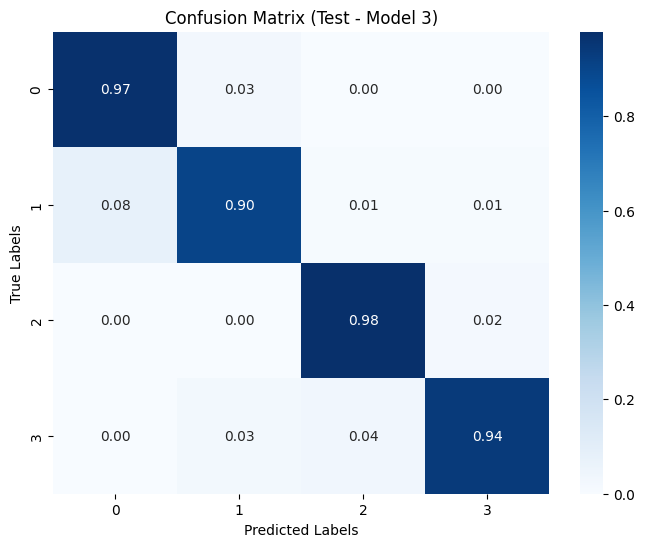


[== Evaluation on External - Model 3 Data ==]
External - Model 3 Loss: 1.8946
External - Model 3 Accuracy: 0.7704

Classification Report (External - Model 3 Data):
              precision    recall  f1-score   support

           0       0.54      0.80      0.64      1008
           1       0.30      0.94      0.45       229
           2       0.26      0.96      0.41       456
           3       0.99      0.75      0.86      9141

    accuracy                           0.77     10834
   macro avg       0.52      0.86      0.59     10834
weighted avg       0.91      0.77      0.81     10834

External - Model 3 AUC: 0.9526


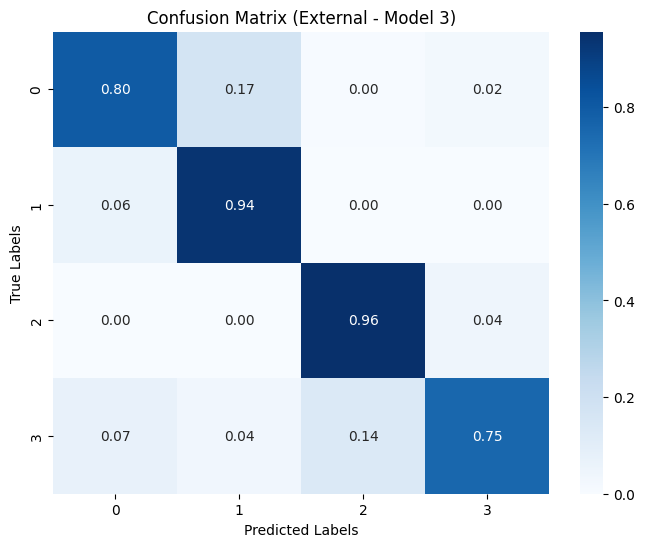

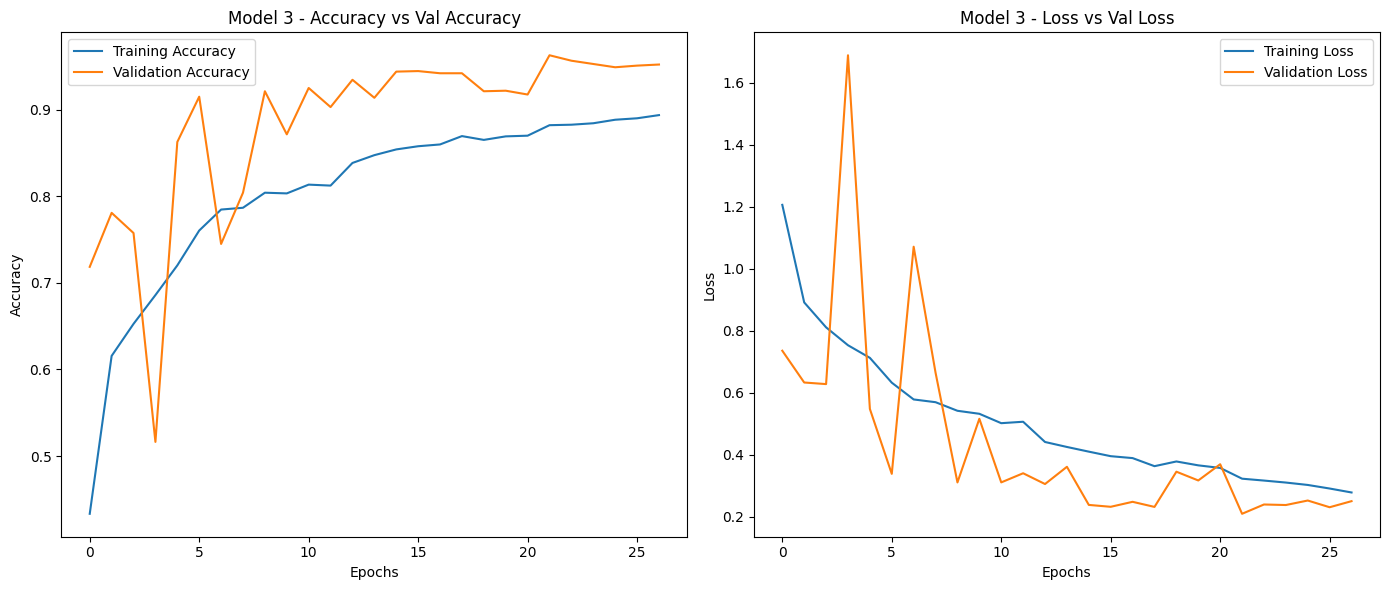


Model 3 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 4/20

Model 4 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.3
  dense_units_2: 32
  dropout_2: 0.35
  learning_rate: 0.0053994234760943605
  weight_decay: 0.007293200489179032
  batch_size: 32

=== Evaluating Model 4 ===

[== Evaluation on Test - Model 4 Data ==]
Test - Model 4 Loss: 0.1528
Test - Model 4 Accuracy: 0.9698

Classification Report (Test - Model 4 Data):
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       112
           1       0.96      0.94      0.95       115
           2       0.98      0.99      0.99       189
           3       0.97      0.95      0.96       114

    accuracy                           0.97       530
   macro avg       0.97      0.97      0.97       530
weighted avg       0.97      0.97      0.97

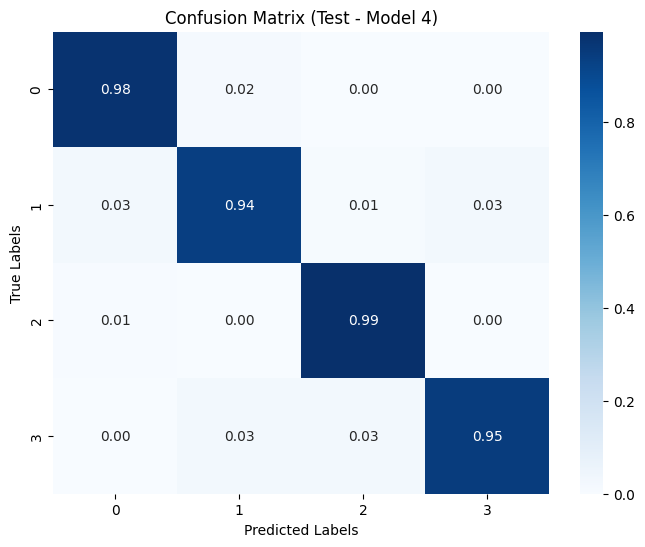


[== Evaluation on External - Model 4 Data ==]
External - Model 4 Loss: 0.8991
External - Model 4 Accuracy: 0.8024

Classification Report (External - Model 4 Data):
              precision    recall  f1-score   support

           0       0.80      0.77      0.78      1008
           1       0.29      0.97      0.44       229
           2       0.25      0.99      0.40       456
           3       1.00      0.79      0.88      9141

    accuracy                           0.80     10834
   macro avg       0.58      0.88      0.63     10834
weighted avg       0.93      0.80      0.84     10834

External - Model 4 AUC: 0.9617


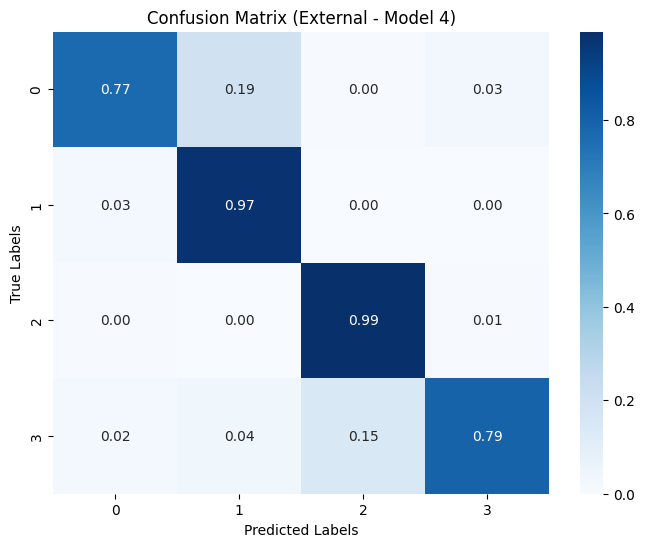

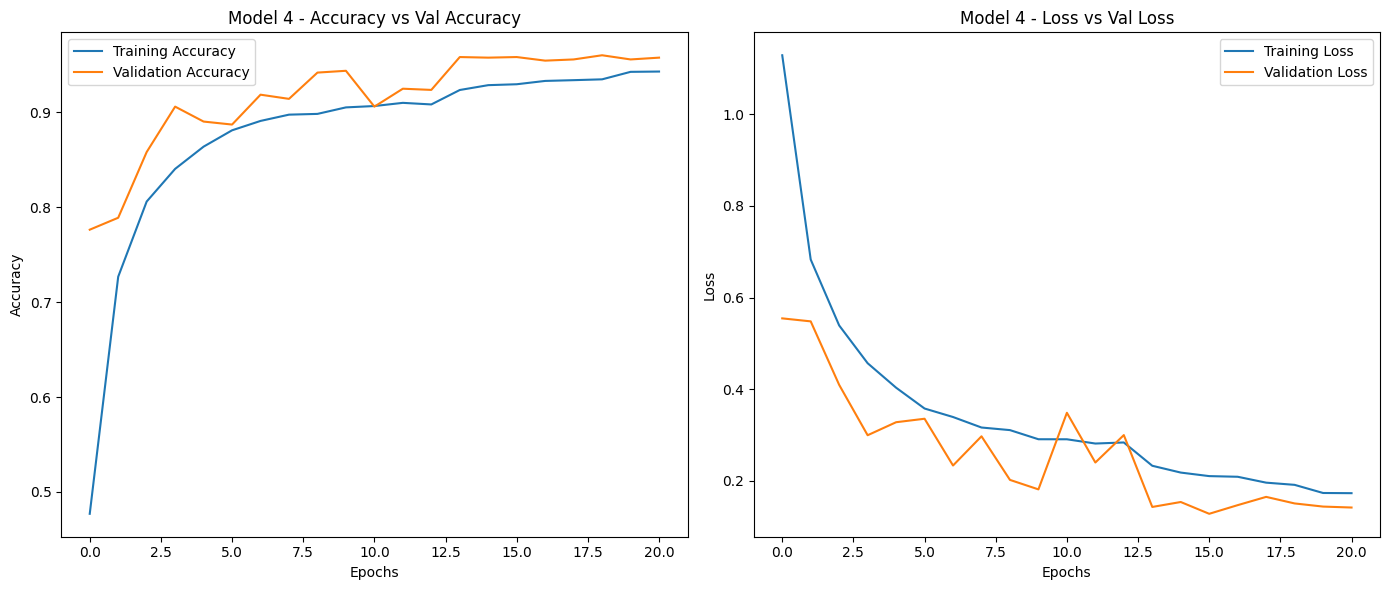


Model 4 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 5/20

Model 5 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.3
  dense_units_2: 32
  dropout_2: 0.5
  learning_rate: 0.007347297879358797
  weight_decay: 0.004063602460736372
  batch_size: 32

=== Evaluating Model 5 ===

[== Evaluation on Test - Model 5 Data ==]
Test - Model 5 Loss: 0.2294
Test - Model 5 Accuracy: 0.9509

Classification Report (Test - Model 5 Data):
              precision    recall  f1-score   support

           0       0.90      0.97      0.94       112
           1       0.96      0.88      0.92       115
           2       0.96      0.99      0.98       189
           3       0.97      0.93      0.95       114

    accuracy                           0.95       530
   macro avg       0.95      0.94      0.95       530
weighted avg       0.95      0.95      0.95  

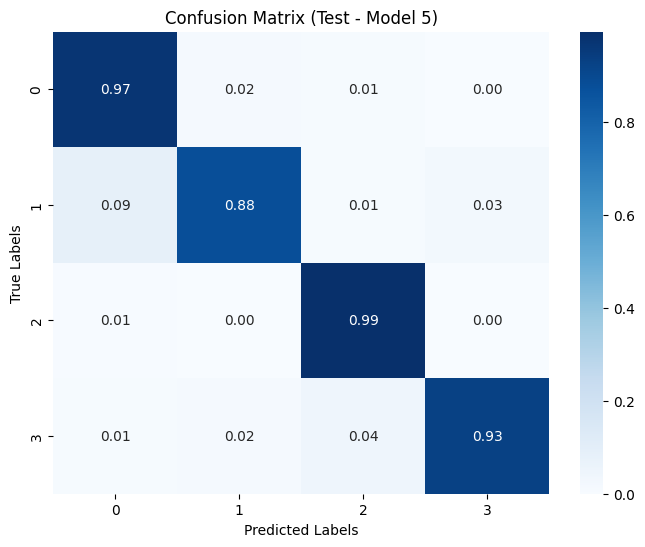


[== Evaluation on External - Model 5 Data ==]
External - Model 5 Loss: 3.2112
External - Model 5 Accuracy: 0.8047

Classification Report (External - Model 5 Data):
              precision    recall  f1-score   support

           0       0.68      0.74      0.71      1008
           1       0.30      0.90      0.45       229
           2       0.26      0.99      0.42       456
           3       0.99      0.80      0.89      9141

    accuracy                           0.80     10834
   macro avg       0.56      0.86      0.62     10834
weighted avg       0.92      0.80      0.84     10834

External - Model 5 AUC: 0.9438


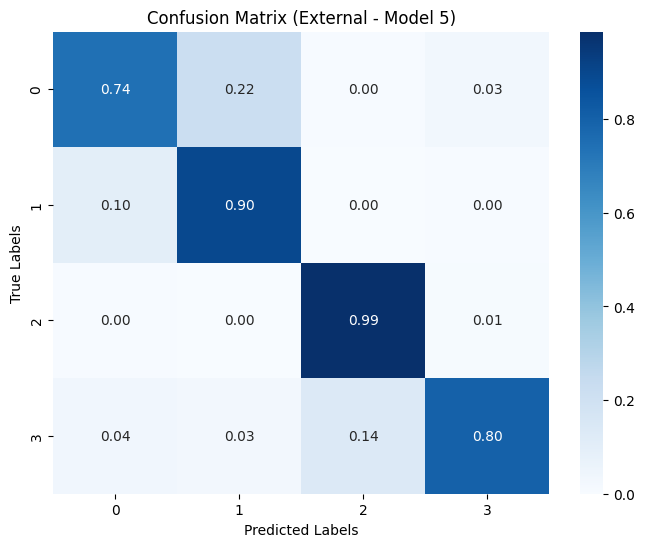

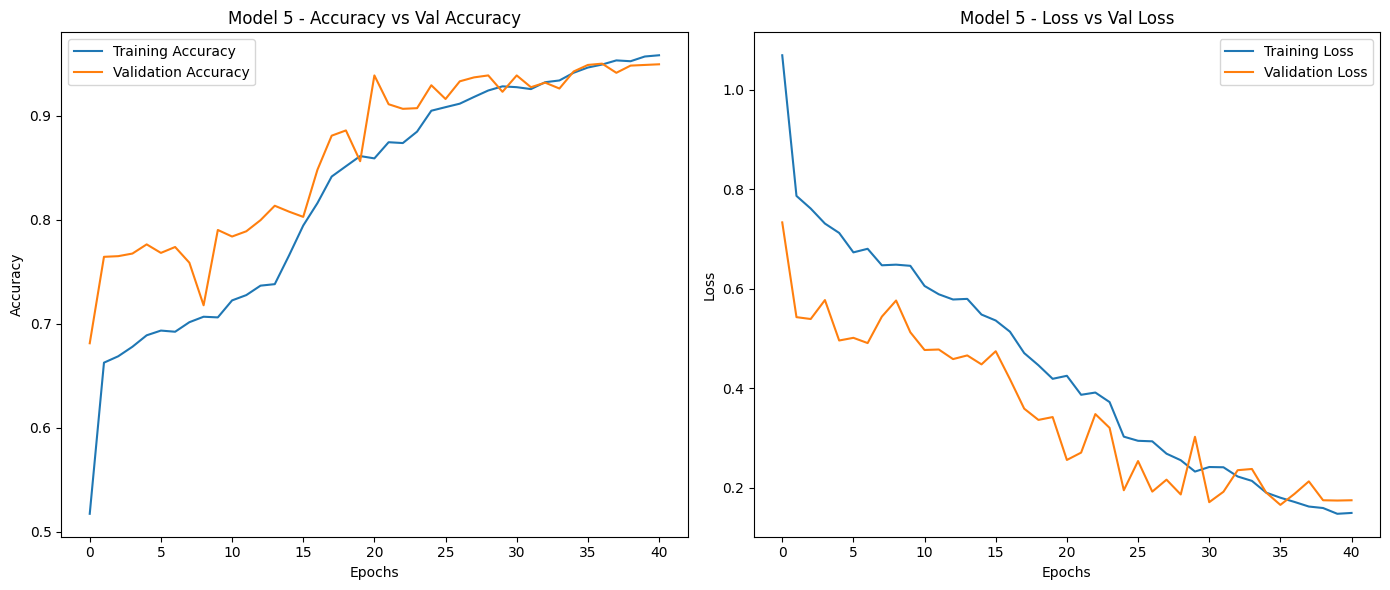


Model 5 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 6/20

Model 6 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 2
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.3
  dense_units_2: 32
  dropout_2: 0.3
  learning_rate: 0.004886669543704227
  weight_decay: 0.00938188040359202
  batch_size: 32

=== Evaluating Model 6 ===

[== Evaluation on Test - Model 6 Data ==]
Test - Model 6 Loss: 0.1167
Test - Model 6 Accuracy: 0.9660

Classification Report (Test - Model 6 Data):
              precision    recall  f1-score   support

           0       0.92      0.99      0.95       112
           1       0.96      0.91      0.94       115
           2       0.99      0.99      0.99       189
           3       0.98      0.96      0.97       114

    accuracy                           0.97       530
   macro avg       0.96      0.96      0.96       530
weighted avg       0.97      0.97      0.97   

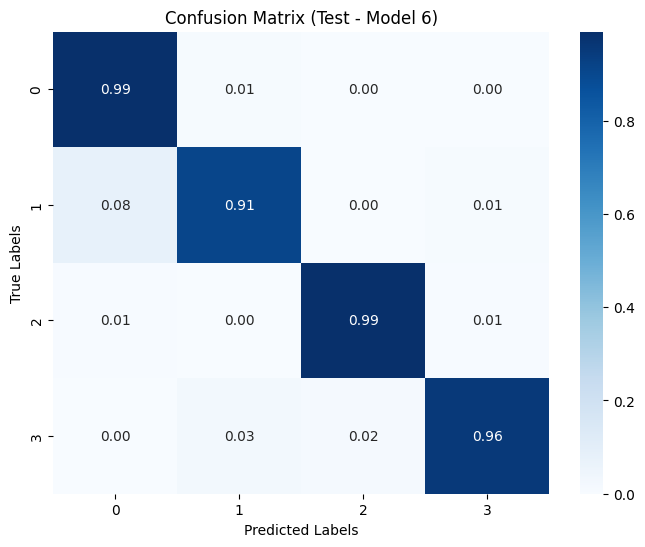


[== Evaluation on External - Model 6 Data ==]
External - Model 6 Loss: 1.0565
External - Model 6 Accuracy: 0.7938

Classification Report (External - Model 6 Data):
              precision    recall  f1-score   support

           0       0.76      0.78      0.77      1008
           1       0.26      0.98      0.41       229
           2       0.25      0.99      0.40       456
           3       1.00      0.78      0.88      9141

    accuracy                           0.79     10834
   macro avg       0.57      0.88      0.62     10834
weighted avg       0.93      0.79      0.84     10834

External - Model 6 AUC: 0.9570


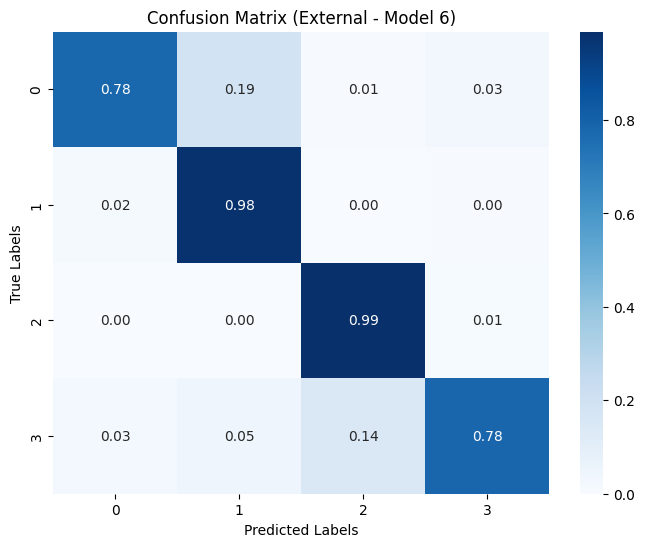

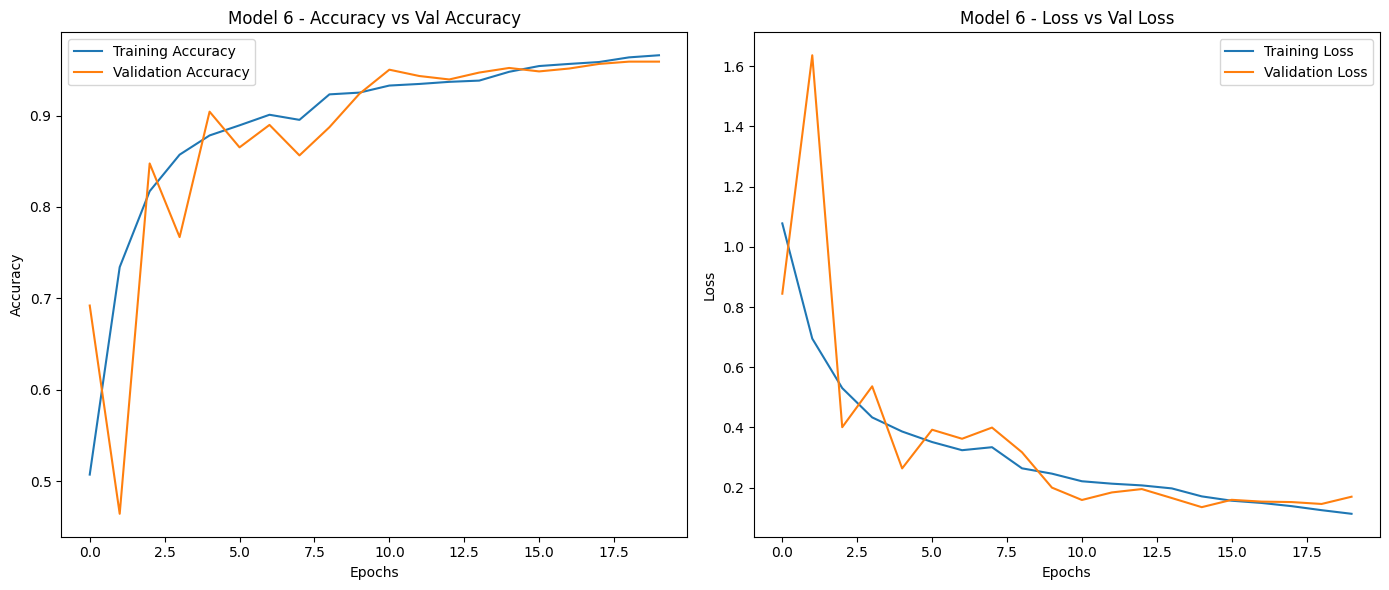


Model 6 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 7/20

Model 7 Hyperparameters:
  f_units: 32
  p_size: 3
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.35
  dense_units_2: 32
  dropout_2: 0.3
  learning_rate: 0.003195541343767252
  weight_decay: 0.0009574109468915371
  batch_size: 32

=== Evaluating Model 7 ===

[== Evaluation on Test - Model 7 Data ==]
Test - Model 7 Loss: 0.1850
Test - Model 7 Accuracy: 0.9491

Classification Report (Test - Model 7 Data):
              precision    recall  f1-score   support

           0       0.89      0.98      0.94       112
           1       0.96      0.89      0.92       115
           2       0.98      0.96      0.97       189
           3       0.94      0.96      0.95       114

    accuracy                           0.95       530
   macro avg       0.95      0.95      0.95       530
weighted avg       0.95      0.95      0.95

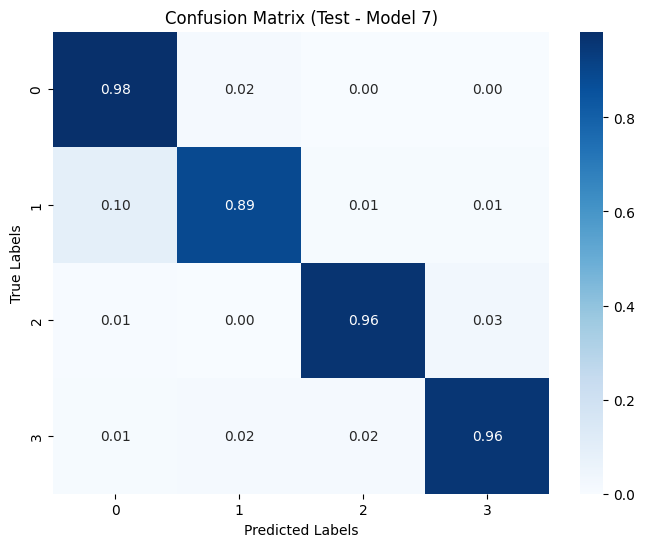


[== Evaluation on External - Model 7 Data ==]
External - Model 7 Loss: 1.4748
External - Model 7 Accuracy: 0.8060

Classification Report (External - Model 7 Data):
              precision    recall  f1-score   support

           0       0.69      0.86      0.77      1008
           1       0.30      0.92      0.45       229
           2       0.27      0.96      0.42       456
           3       0.99      0.79      0.88      9141

    accuracy                           0.81     10834
   macro avg       0.56      0.88      0.63     10834
weighted avg       0.92      0.81      0.84     10834

External - Model 7 AUC: 0.9594


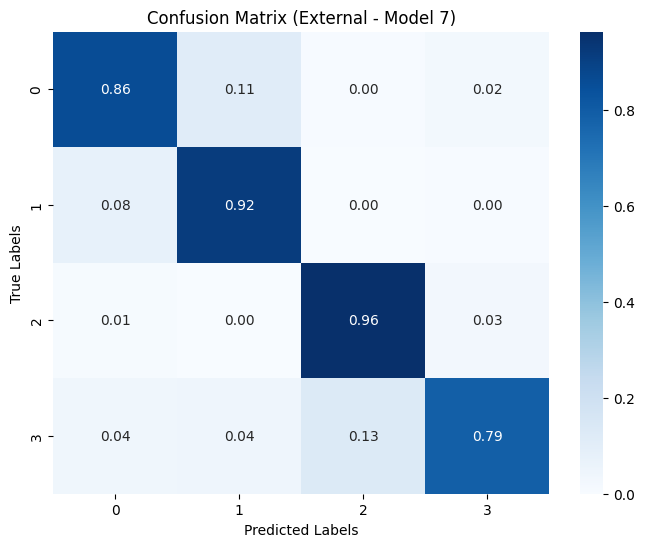

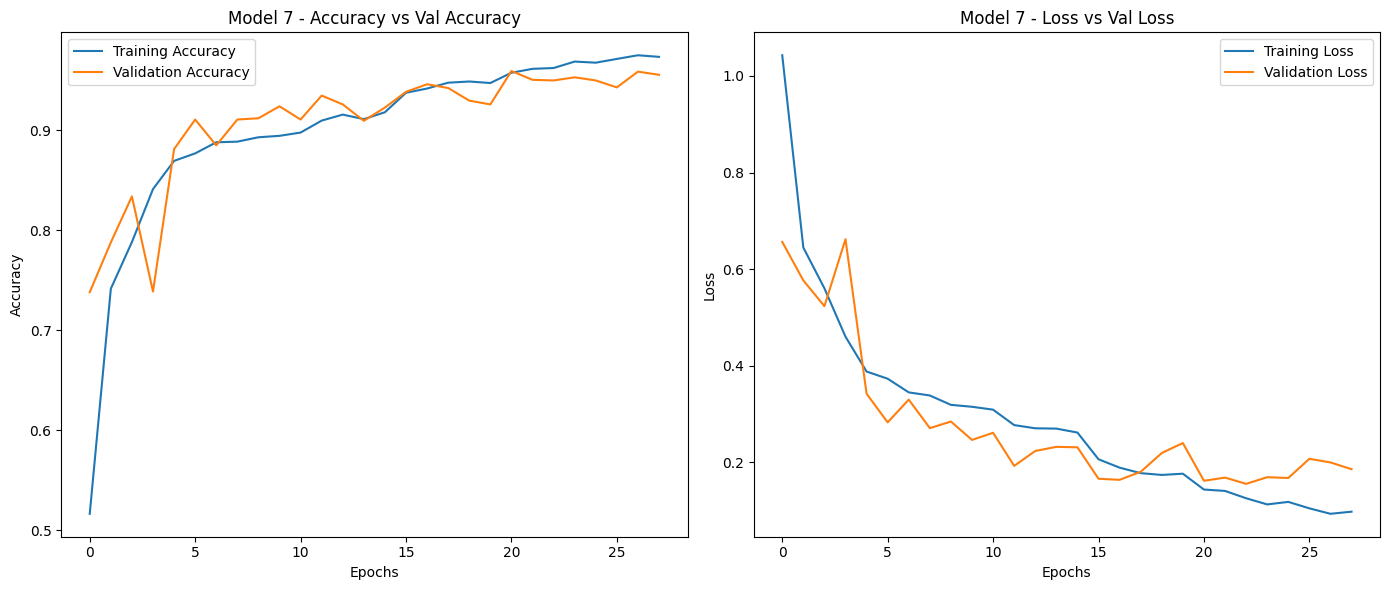


Model 7 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 8/20

Model 8 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.3
  dense_units_2: 32
  dropout_2: 0.5
  learning_rate: 0.005332467670301351
  weight_decay: 0.004898487101086894
  batch_size: 32

=== Evaluating Model 8 ===

[== Evaluation on Test - Model 8 Data ==]
Test - Model 8 Loss: 0.2568
Test - Model 8 Accuracy: 0.9358

Classification Report (Test - Model 8 Data):
              precision    recall  f1-score   support

           0       0.86      0.95      0.90       112
           1       0.93      0.84      0.89       115
           2       0.98      0.97      0.98       189
           3       0.95      0.96      0.95       114

    accuracy                           0.94       530
   macro avg       0.93      0.93      0.93       530
weighted avg       0.94      0.94      0.94  

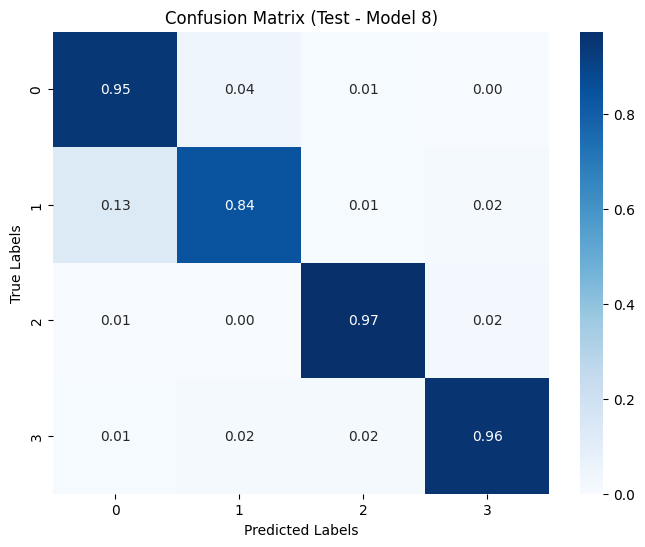


[== Evaluation on External - Model 8 Data ==]
External - Model 8 Loss: 1.5875
External - Model 8 Accuracy: 0.8009

Classification Report (External - Model 8 Data):
              precision    recall  f1-score   support

           0       0.73      0.79      0.76      1008
           1       0.29      0.91      0.44       229
           2       0.25      0.98      0.40       456
           3       0.99      0.79      0.88      9141

    accuracy                           0.80     10834
   macro avg       0.57      0.87      0.62     10834
weighted avg       0.92      0.80      0.84     10834

External - Model 8 AUC: 0.9544


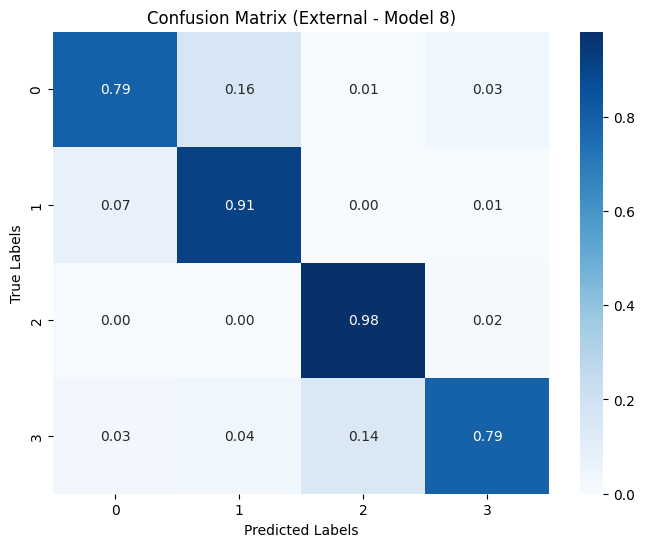

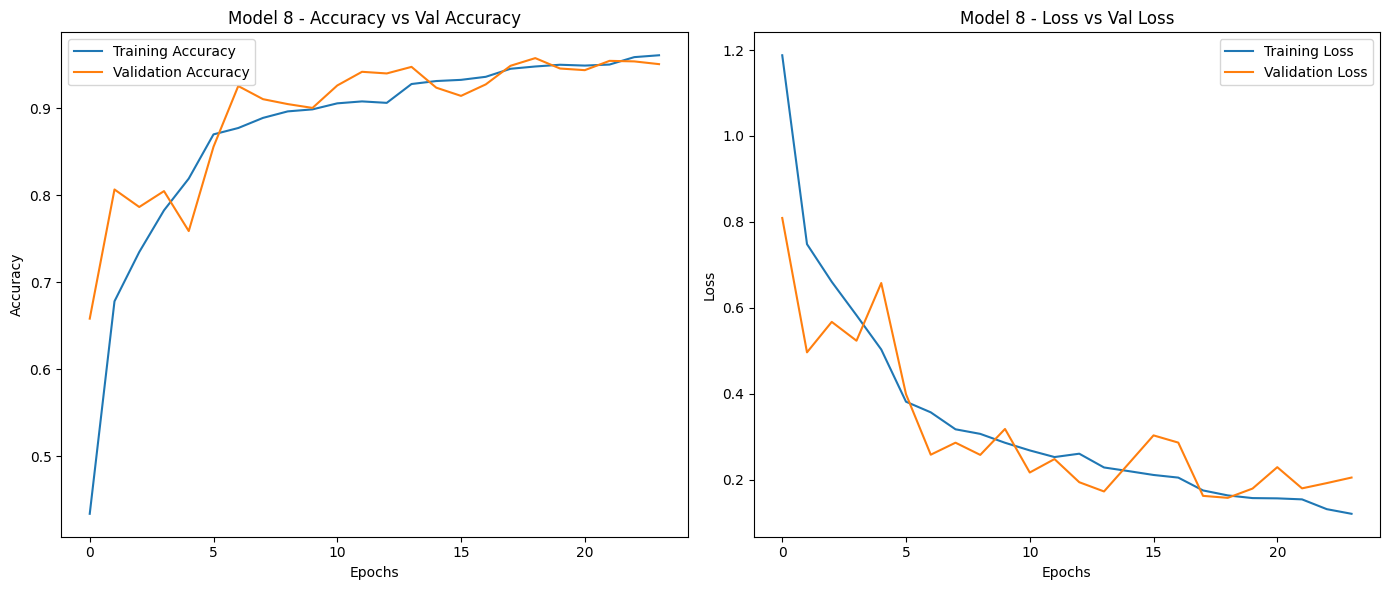


Model 8 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 9/20

Model 9 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.3
  dense_units_2: 32
  dropout_2: 0.3
  learning_rate: 0.006641449869985324
  weight_decay: 0.007571340132966641
  batch_size: 32

=== Evaluating Model 9 ===

[== Evaluation on Test - Model 9 Data ==]
Test - Model 9 Loss: 0.1583
Test - Model 9 Accuracy: 0.9679

Classification Report (Test - Model 9 Data):
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       112
           1       0.94      0.96      0.95       115
           2       0.97      1.00      0.98       189
           3       0.99      0.93      0.96       114

    accuracy                           0.97       530
   macro avg       0.97      0.96      0.97       530
weighted avg       0.97      0.97      0.97  

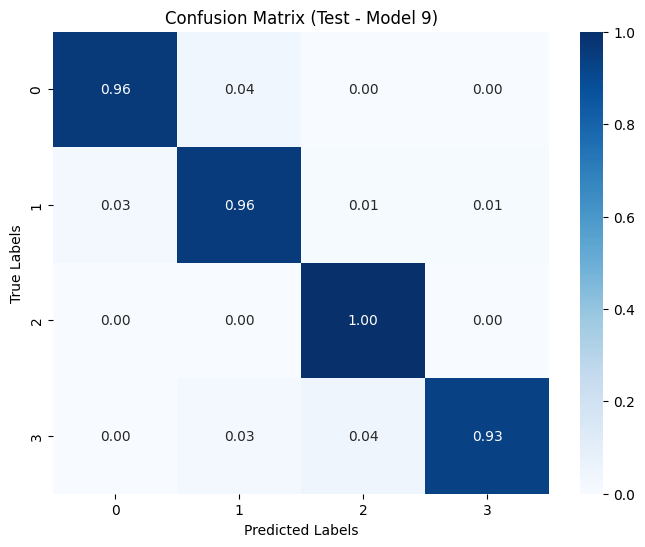


[== Evaluation on External - Model 9 Data ==]
External - Model 9 Loss: 1.4156
External - Model 9 Accuracy: 0.7788

Classification Report (External - Model 9 Data):
              precision    recall  f1-score   support

           0       0.79      0.67      0.72      1008
           1       0.21      0.97      0.34       229
           2       0.25      0.97      0.40       456
           3       0.99      0.78      0.87      9141

    accuracy                           0.78     10834
   macro avg       0.56      0.85      0.58     10834
weighted avg       0.93      0.78      0.83     10834

External - Model 9 AUC: 0.9367


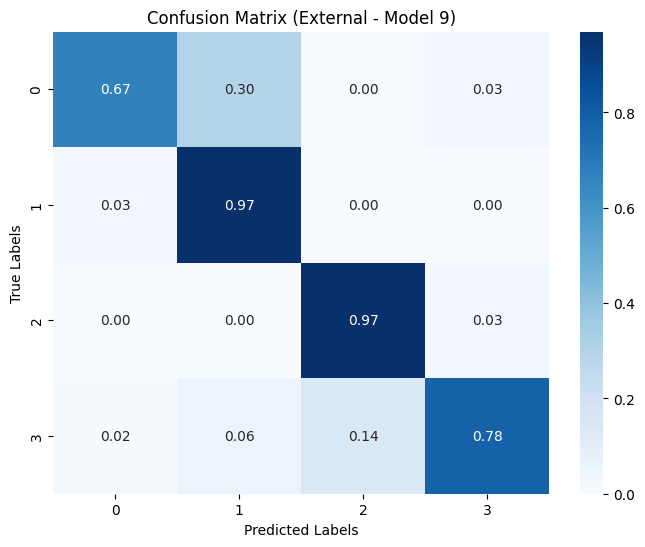

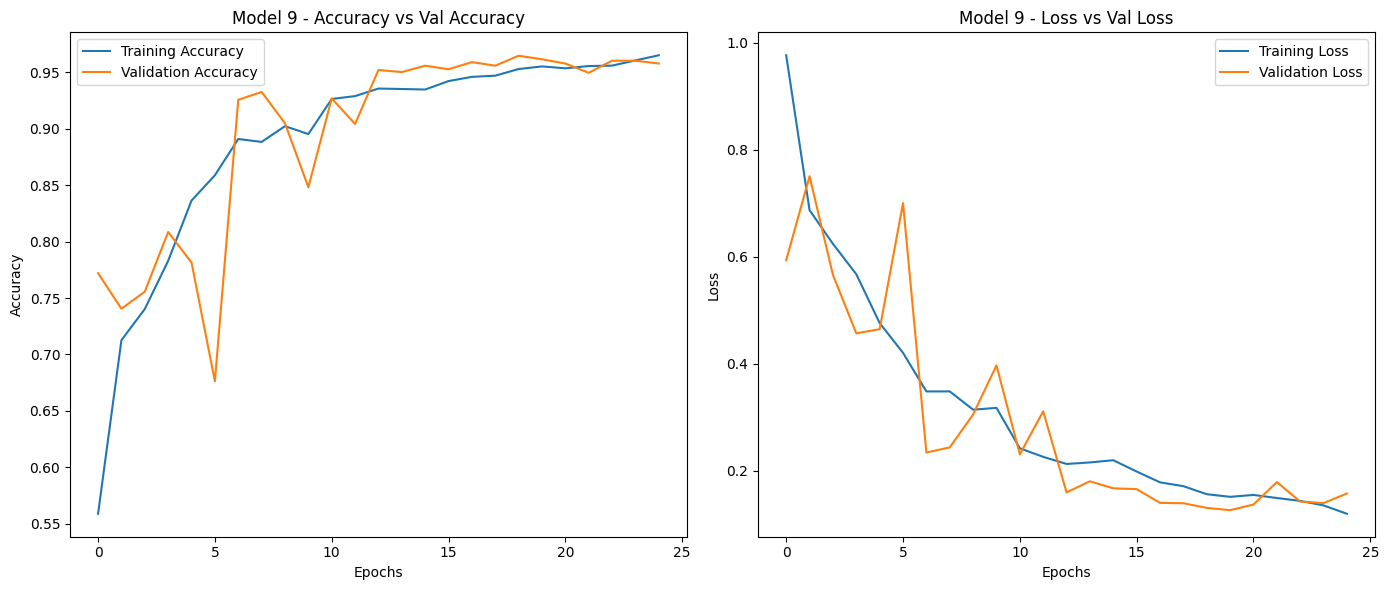


Model 9 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 10/20

Model 10 Hyperparameters:
  f_units: 32
  p_size: 2
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 32
  dropout_1: 0.3
  dense_units_2: 64
  dropout_2: 0.3
  learning_rate: 0.003599962535394554
  weight_decay: 0.005408523572776047
  batch_size: 32

=== Evaluating Model 10 ===

[== Evaluation on Test - Model 10 Data ==]
Test - Model 10 Loss: 0.1708
Test - Model 10 Accuracy: 0.9585

Classification Report (Test - Model 10 Data):
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       112
           1       0.92      0.94      0.93       115
           2       0.98      0.98      0.98       189
           3       0.97      0.95      0.96       114

    accuracy                           0.96       530
   macro avg       0.96      0.95      0.95       530
weighted avg       0.96      0.96     

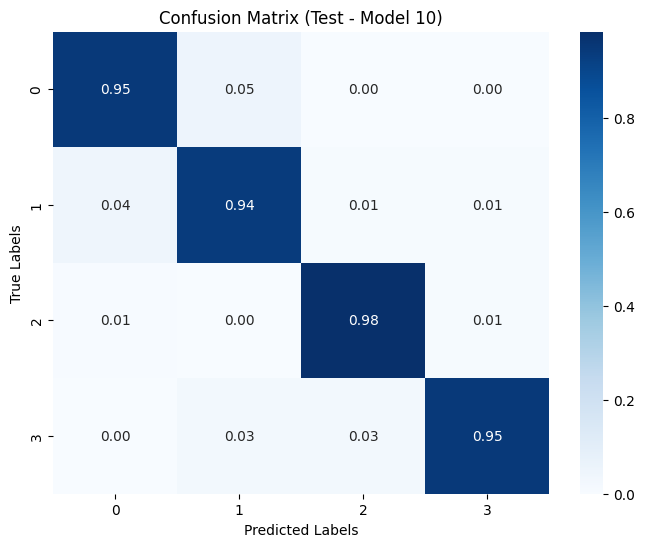


[== Evaluation on External - Model 10 Data ==]
External - Model 10 Loss: 1.2141
External - Model 10 Accuracy: 0.7729

Classification Report (External - Model 10 Data):
              precision    recall  f1-score   support

           0       0.68      0.75      0.71      1008
           1       0.22      0.97      0.36       229
           2       0.26      0.98      0.41       456
           3       0.99      0.76      0.86      9141

    accuracy                           0.77     10834
   macro avg       0.54      0.87      0.59     10834
weighted avg       0.92      0.77      0.82     10834

External - Model 10 AUC: 0.9562


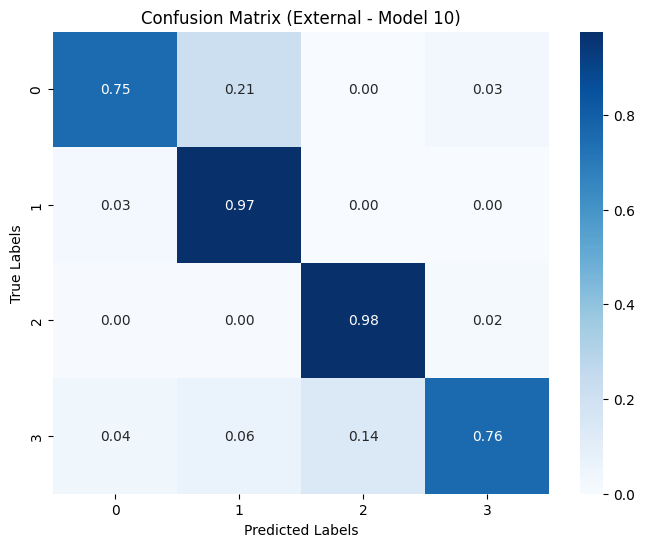

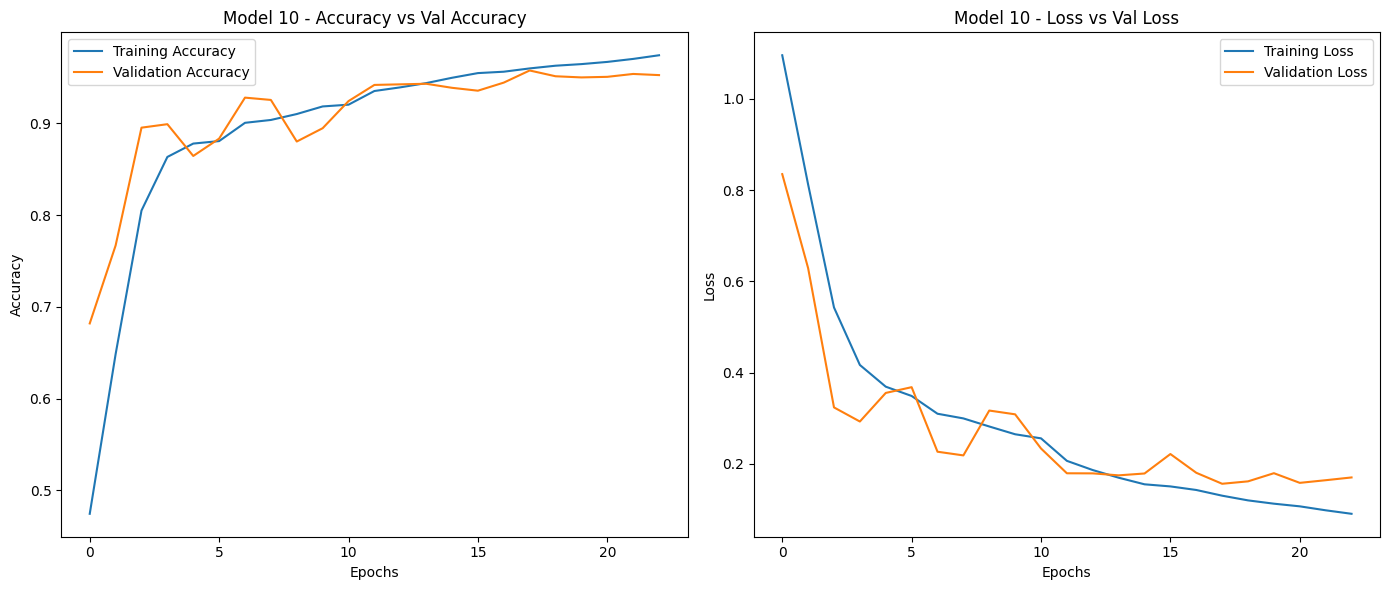


Model 10 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 11/20

Model 11 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.3
  dense_units_2: 32
  dropout_2: 0.5
  learning_rate: 0.007079167921483133
  weight_decay: 0.004183112119738697
  batch_size: 32

=== Evaluating Model 11 ===

[== Evaluation on Test - Model 11 Data ==]
Test - Model 11 Loss: 0.1747
Test - Model 11 Accuracy: 0.9604

Classification Report (Test - Model 11 Data):
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       112
           1       0.95      0.95      0.95       115
           2       0.96      0.99      0.98       189
           3       0.97      0.93      0.95       114

    accuracy                           0.96       530
   macro avg       0.96      0.96      0.96       530
weighted avg       0.96      0.96    

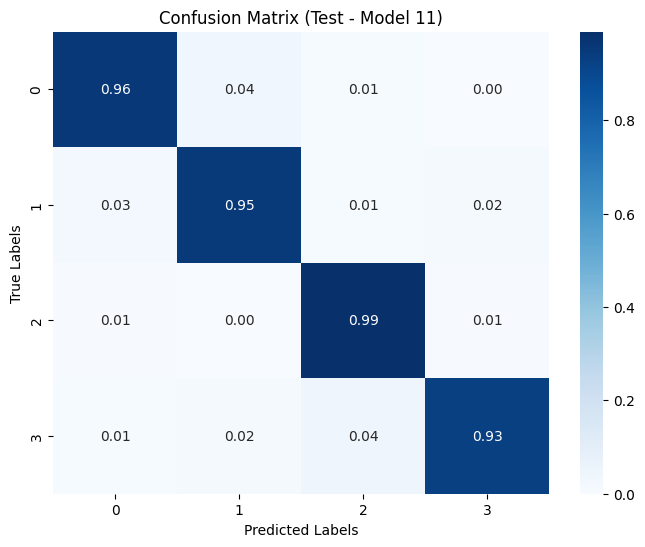


[== Evaluation on External - Model 11 Data ==]
External - Model 11 Loss: 1.1989
External - Model 11 Accuracy: 0.7798

Classification Report (External - Model 11 Data):
              precision    recall  f1-score   support

           0       0.58      0.82      0.68      1008
           1       0.30      0.96      0.46       229
           2       0.26      0.98      0.41       456
           3       0.99      0.76      0.86      9141

    accuracy                           0.78     10834
   macro avg       0.54      0.88      0.60     10834
weighted avg       0.91      0.78      0.82     10834

External - Model 11 AUC: 0.9592


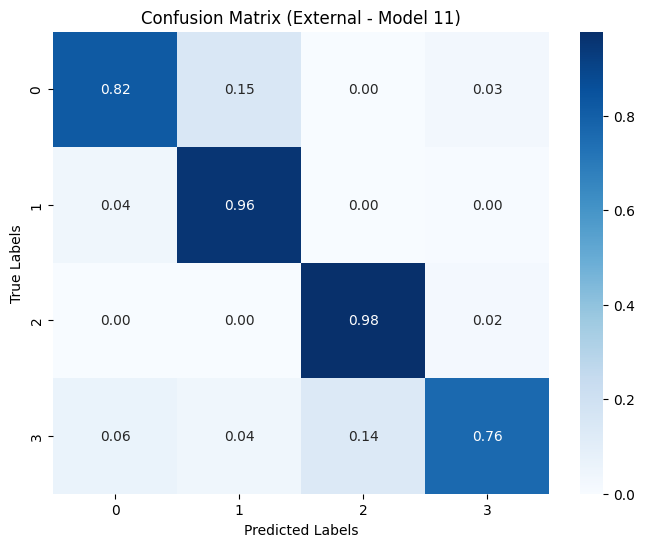

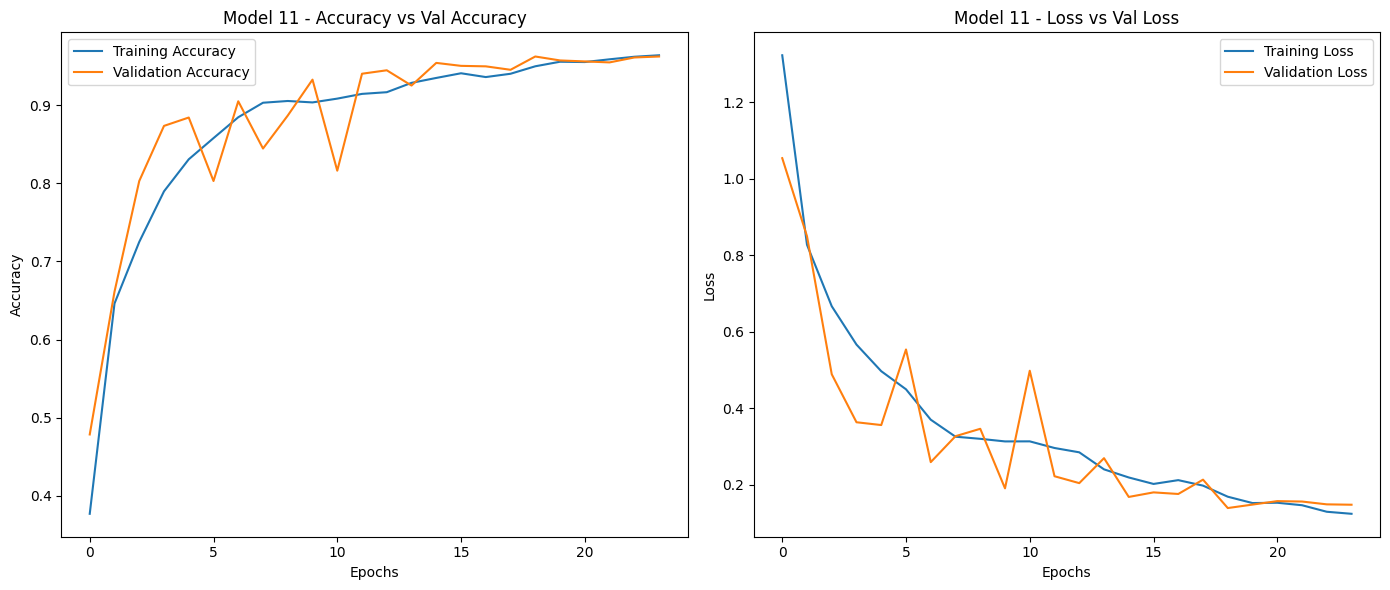


Model 11 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 12/20

Model 12 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.3
  dense_units_2: 32
  dropout_2: 0.5
  learning_rate: 0.006669964627715346
  weight_decay: 0.003654300673475232
  batch_size: 32

=== Evaluating Model 12 ===

[== Evaluation on Test - Model 12 Data ==]
Test - Model 12 Loss: 0.1553
Test - Model 12 Accuracy: 0.9623

Classification Report (Test - Model 12 Data):
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       112
           1       0.92      0.94      0.93       115
           2       0.98      0.99      0.99       189
           3       0.99      0.94      0.96       114

    accuracy                           0.96       530
   macro avg       0.96      0.96      0.96       530
weighted avg       0.96      0.96    

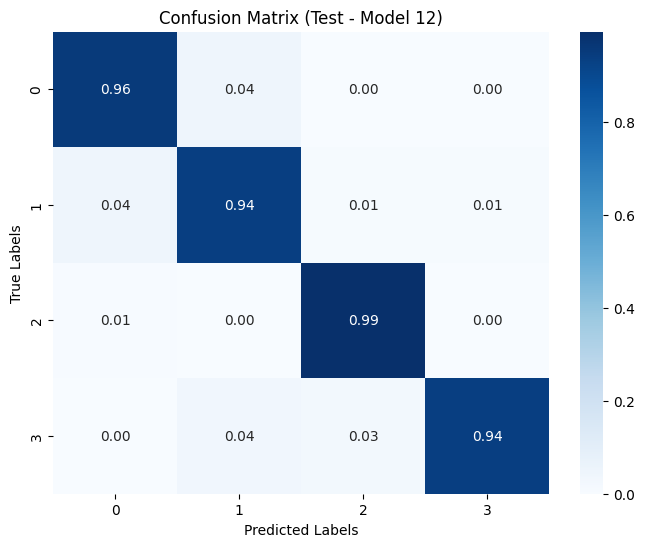


[== Evaluation on External - Model 12 Data ==]
External - Model 12 Loss: 1.4952
External - Model 12 Accuracy: 0.7518

Classification Report (External - Model 12 Data):
              precision    recall  f1-score   support

           0       0.53      0.72      0.61      1008
           1       0.22      0.98      0.36       229
           2       0.26      0.97      0.42       456
           3       1.00      0.74      0.85      9141

    accuracy                           0.75     10834
   macro avg       0.50      0.85      0.56     10834
weighted avg       0.91      0.75      0.80     10834

External - Model 12 AUC: 0.9519


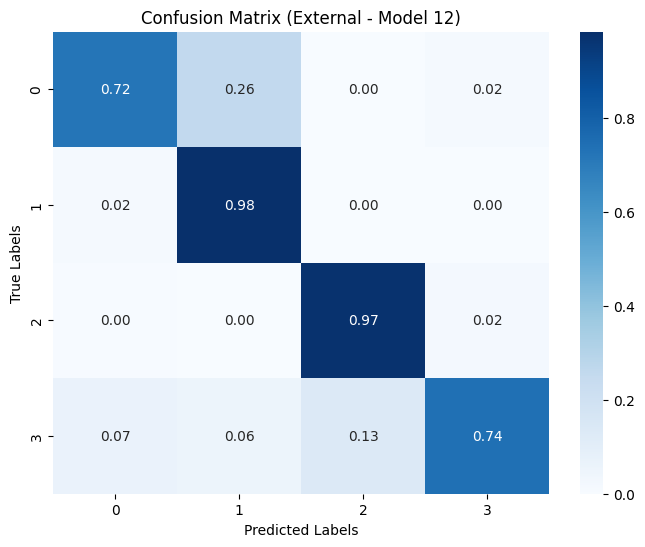

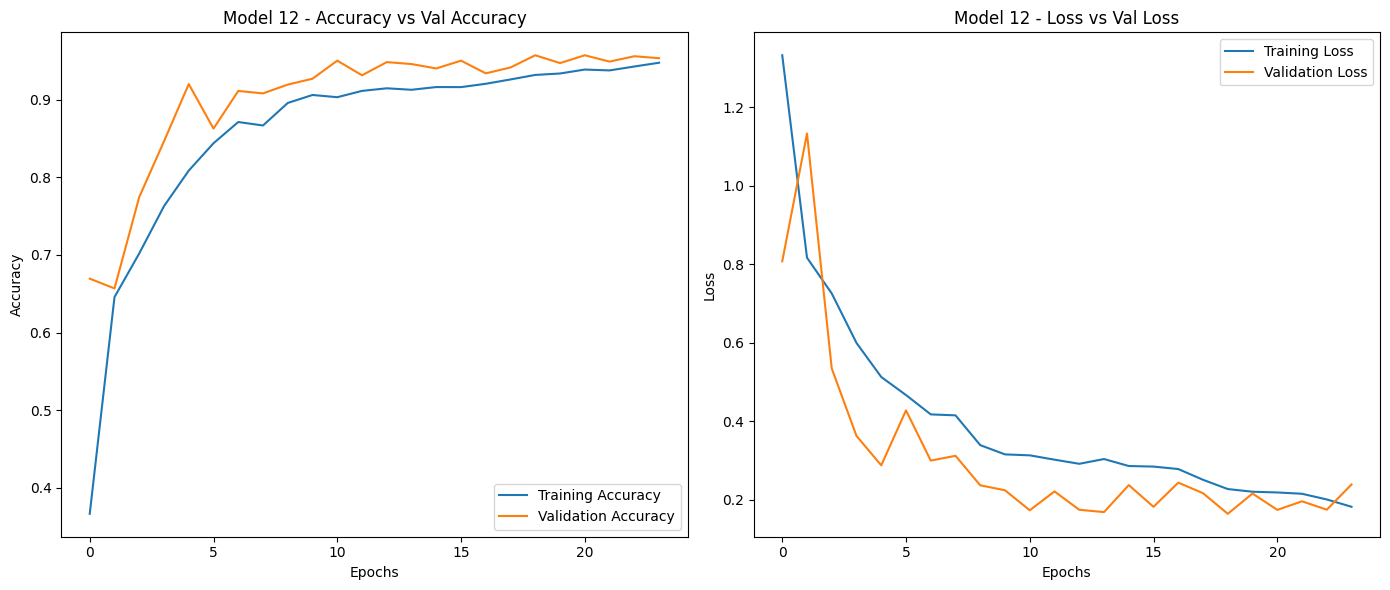


Model 12 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 13/20

Model 13 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.3
  dense_units_2: 32
  dropout_2: 0.5
  learning_rate: 0.007373413386591466
  weight_decay: 0.00402714930176548
  batch_size: 32

=== Evaluating Model 13 ===

[== Evaluation on Test - Model 13 Data ==]
Test - Model 13 Loss: 0.1442
Test - Model 13 Accuracy: 0.9585

Classification Report (Test - Model 13 Data):
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       112
           1       0.93      0.91      0.92       115
           2       0.98      0.99      0.99       189
           3       0.98      0.96      0.97       114

    accuracy                           0.96       530
   macro avg       0.95      0.95      0.95       530
weighted avg       0.96      0.96     

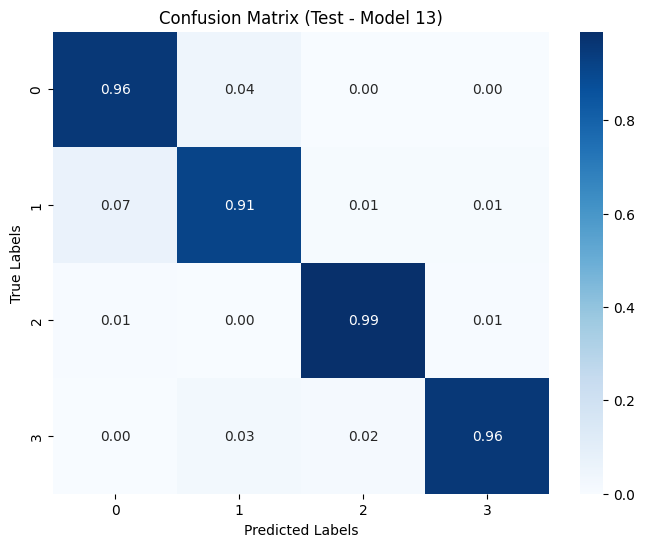


[== Evaluation on External - Model 13 Data ==]
External - Model 13 Loss: 1.5031
External - Model 13 Accuracy: 0.7356

Classification Report (External - Model 13 Data):
              precision    recall  f1-score   support

           0       0.44      0.80      0.57      1008
           1       0.28      0.91      0.42       229
           2       0.26      0.97      0.41       456
           3       1.00      0.71      0.83      9141

    accuracy                           0.74     10834
   macro avg       0.49      0.85      0.56     10834
weighted avg       0.90      0.74      0.78     10834

External - Model 13 AUC: 0.9513


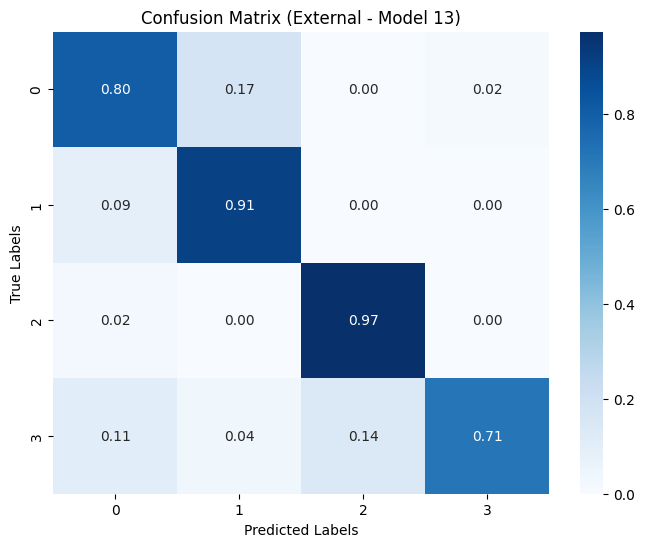

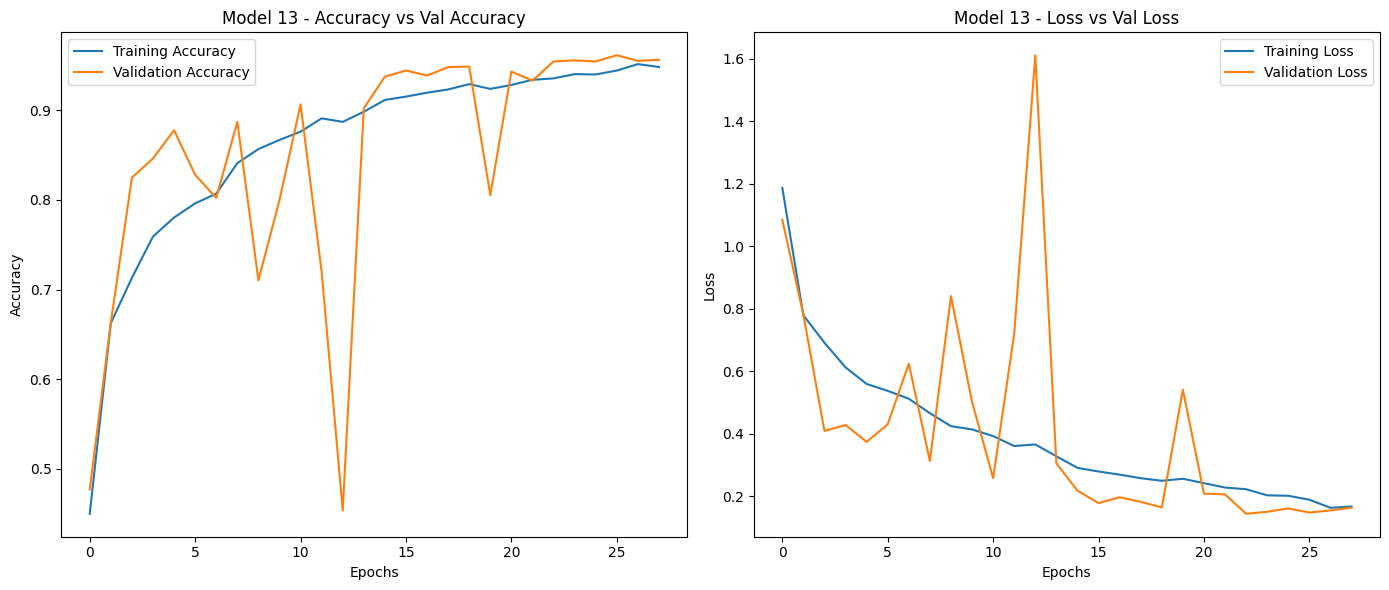


Model 13 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 14/20

Model 14 Hyperparameters:
  f_units: 32
  p_size: 3
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.3
  dense_units_2: 32
  dropout_2: 0.45
  learning_rate: 0.004835285244155431
  weight_decay: 0.004898617918256984
  batch_size: 32

=== Evaluating Model 14 ===

[== Evaluation on Test - Model 14 Data ==]
Test - Model 14 Loss: 0.1762
Test - Model 14 Accuracy: 0.9491

Classification Report (Test - Model 14 Data):
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       112
           1       0.93      0.94      0.94       115
           2       0.99      0.95      0.97       189
           3       0.91      0.96      0.94       114

    accuracy                           0.95       530
   macro avg       0.94      0.95      0.95       530
weighted avg       0.95      0.95   

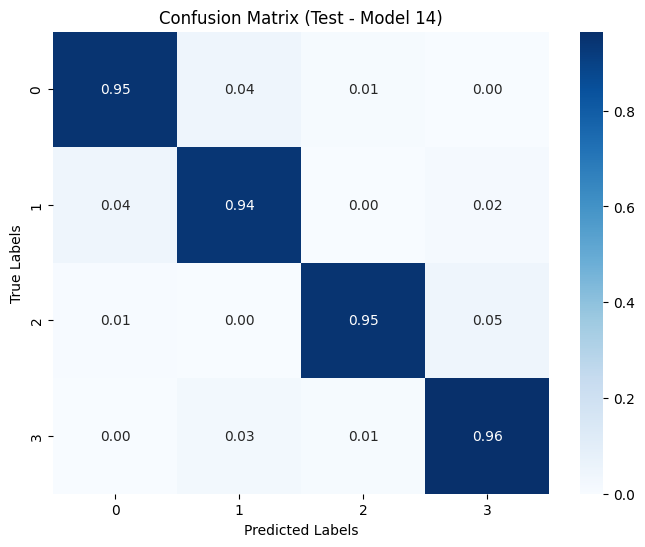


[== Evaluation on External - Model 14 Data ==]
External - Model 14 Loss: 1.2400
External - Model 14 Accuracy: 0.8196

Classification Report (External - Model 14 Data):
              precision    recall  f1-score   support

           0       0.82      0.71      0.76      1008
           1       0.25      0.98      0.40       229
           2       0.28      0.92      0.43       456
           3       0.99      0.82      0.90      9141

    accuracy                           0.82     10834
   macro avg       0.59      0.86      0.62     10834
weighted avg       0.93      0.82      0.86     10834

External - Model 14 AUC: 0.9408


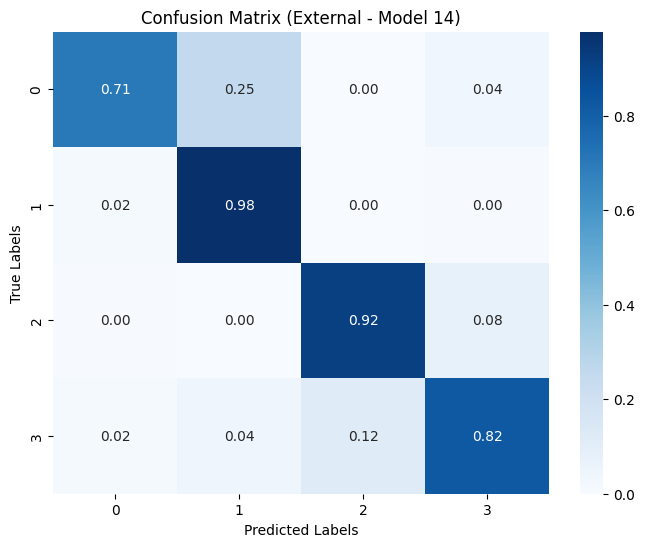

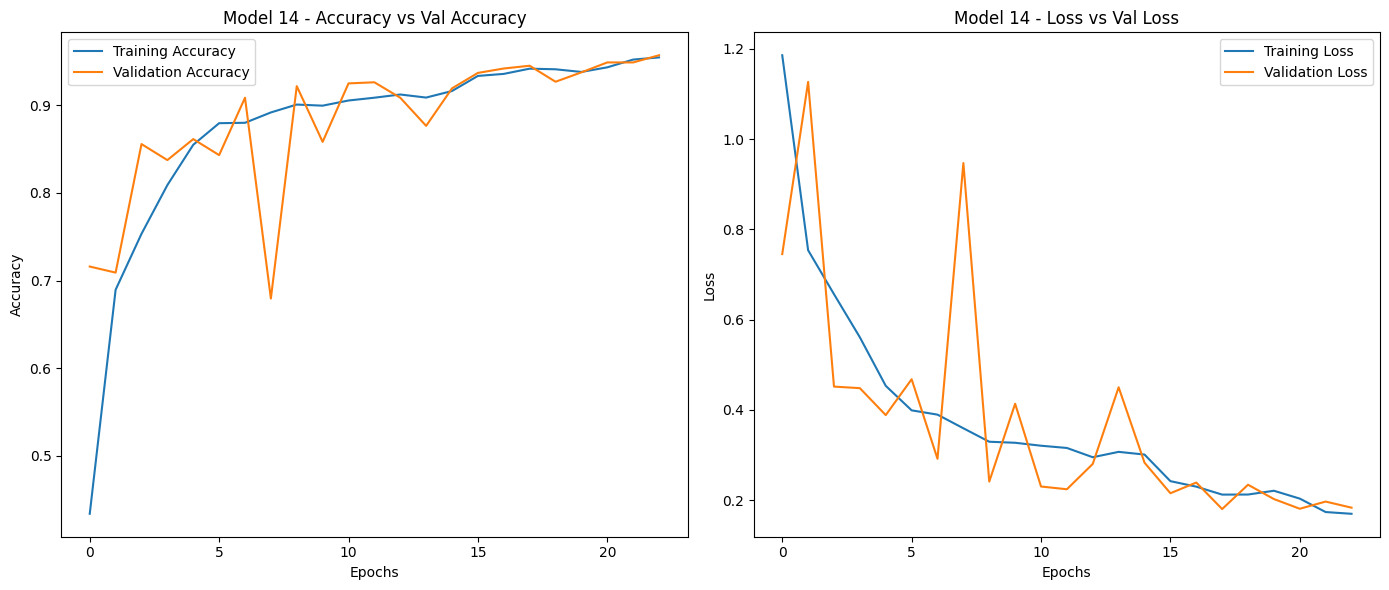


Model 14 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 15/20

Model 15 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 2
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.3
  dense_units_2: 32
  dropout_2: 0.5
  learning_rate: 0.007342562778278435
  weight_decay: 0.004143959494820622
  batch_size: 32

=== Evaluating Model 15 ===

[== Evaluation on Test - Model 15 Data ==]
Test - Model 15 Loss: 0.1744
Test - Model 15 Accuracy: 0.9547

Classification Report (Test - Model 15 Data):
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       112
           1       0.92      0.94      0.93       115
           2       0.98      0.98      0.98       189
           3       0.98      0.95      0.96       114

    accuracy                           0.95       530
   macro avg       0.95      0.95      0.95       530
weighted avg       0.96      0.95    

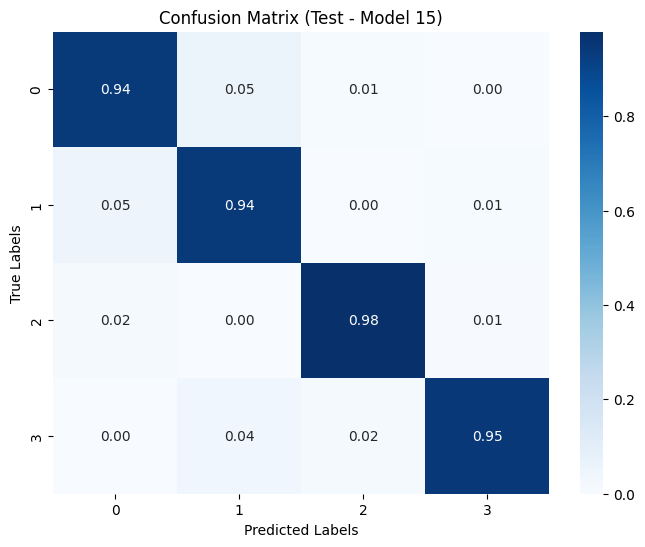


[== Evaluation on External - Model 15 Data ==]
External - Model 15 Loss: 1.3279
External - Model 15 Accuracy: 0.7702

Classification Report (External - Model 15 Data):
              precision    recall  f1-score   support

           0       0.62      0.78      0.69      1008
           1       0.22      1.00      0.36       229
           2       0.27      0.91      0.41       456
           3       0.99      0.76      0.86      9141

    accuracy                           0.77     10834
   macro avg       0.52      0.86      0.58     10834
weighted avg       0.91      0.77      0.81     10834

External - Model 15 AUC: 0.9539


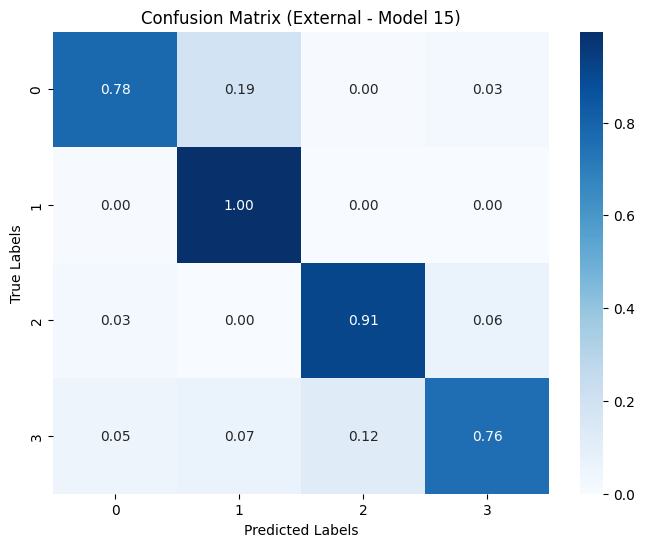

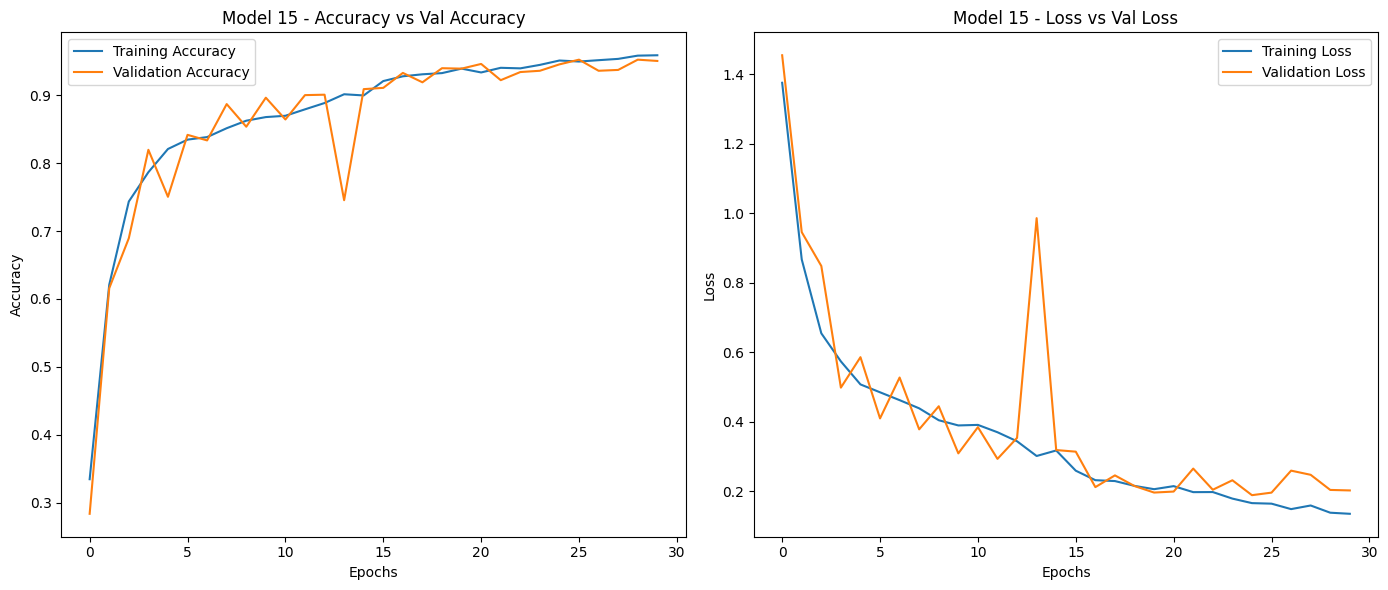


Model 15 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 16/20

Model 16 Hyperparameters:
  f_units: 32
  p_size: 3
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.35
  dense_units_2: 64
  dropout_2: 0.3
  learning_rate: 0.0033390822033851405
  weight_decay: 0.009536036199024572
  batch_size: 32

=== Evaluating Model 16 ===

[== Evaluation on Test - Model 16 Data ==]
Test - Model 16 Loss: 0.1534
Test - Model 16 Accuracy: 0.9566

Classification Report (Test - Model 16 Data):
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       112
           1       0.94      0.90      0.92       115
           2       0.98      0.99      0.98       189
           3       0.98      0.95      0.96       114

    accuracy                           0.96       530
   macro avg       0.95      0.95      0.95       530
weighted avg       0.96      0.96  

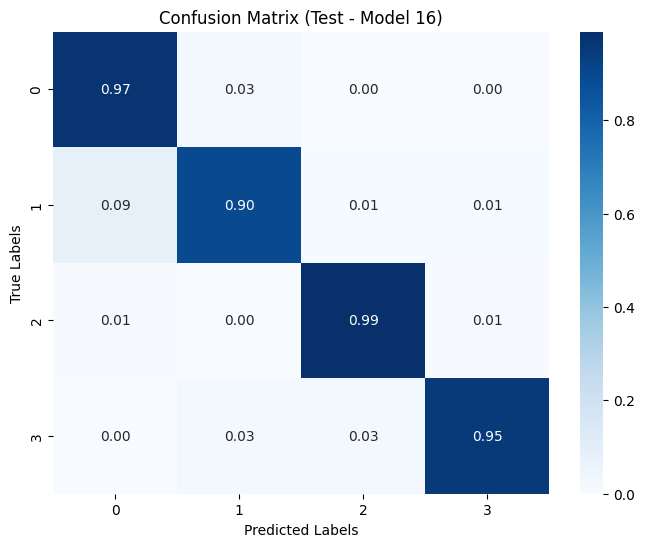


[== Evaluation on External - Model 16 Data ==]
External - Model 16 Loss: 1.1067
External - Model 16 Accuracy: 0.7799

Classification Report (External - Model 16 Data):
              precision    recall  f1-score   support

           0       0.70      0.82      0.76      1008
           1       0.25      0.97      0.39       229
           2       0.25      0.98      0.40       456
           3       1.00      0.76      0.86      9141

    accuracy                           0.78     10834
   macro avg       0.55      0.89      0.60     10834
weighted avg       0.92      0.78      0.82     10834

External - Model 16 AUC: 0.9666


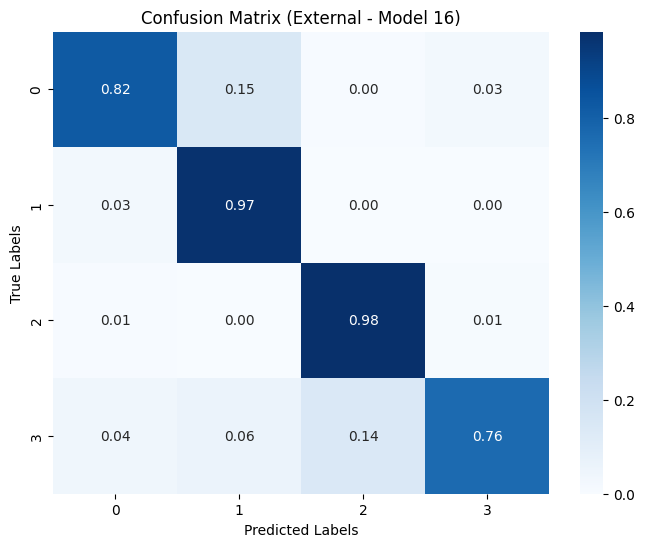

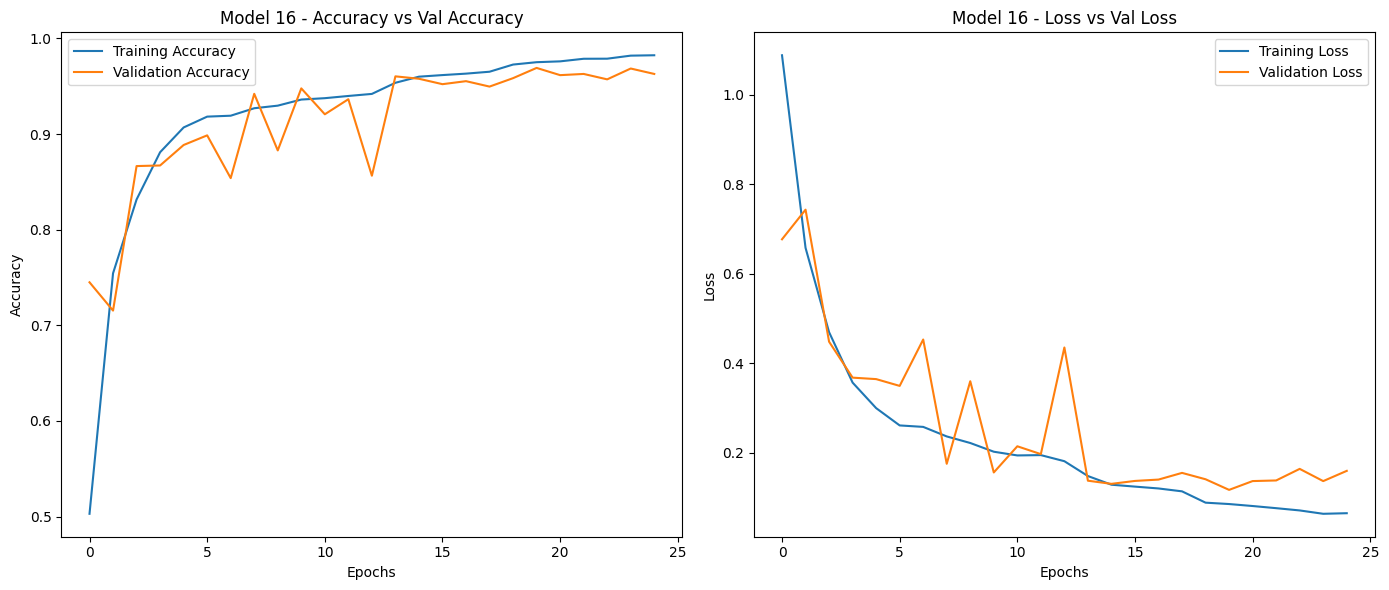


Model 16 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 17/20

Model 17 Hyperparameters:
  f_units: 32
  p_size: 2
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 32
  dropout_1: 0.4
  dense_units_2: 64
  dropout_2: 0.45
  learning_rate: 0.0021568727250812878
  weight_decay: 0.00014273202424071565
  batch_size: 32

=== Evaluating Model 17 ===

[== Evaluation on Test - Model 17 Data ==]
Test - Model 17 Loss: 0.2026
Test - Model 17 Accuracy: 0.9358

Classification Report (Test - Model 17 Data):
              precision    recall  f1-score   support

           0       0.86      0.93      0.89       112
           1       0.92      0.84      0.88       115
           2       0.96      1.00      0.98       189
           3       0.98      0.93      0.95       114

    accuracy                           0.94       530
   macro avg       0.93      0.93      0.93       530
weighted avg       0.94      0.94

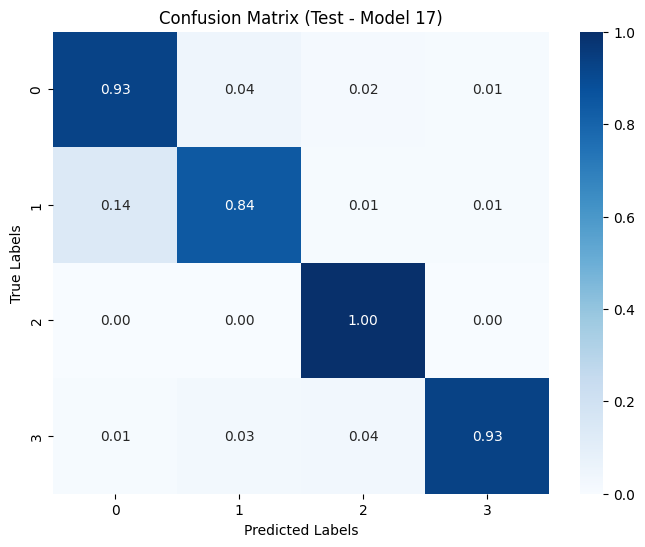


[== Evaluation on External - Model 17 Data ==]
External - Model 17 Loss: 0.9866
External - Model 17 Accuracy: 0.7851

Classification Report (External - Model 17 Data):
              precision    recall  f1-score   support

           0       0.70      0.77      0.73      1008
           1       0.27      0.93      0.41       229
           2       0.25      0.99      0.39       456
           3       1.00      0.77      0.87      9141

    accuracy                           0.79     10834
   macro avg       0.55      0.86      0.60     10834
weighted avg       0.92      0.79      0.83     10834

External - Model 17 AUC: 0.9589


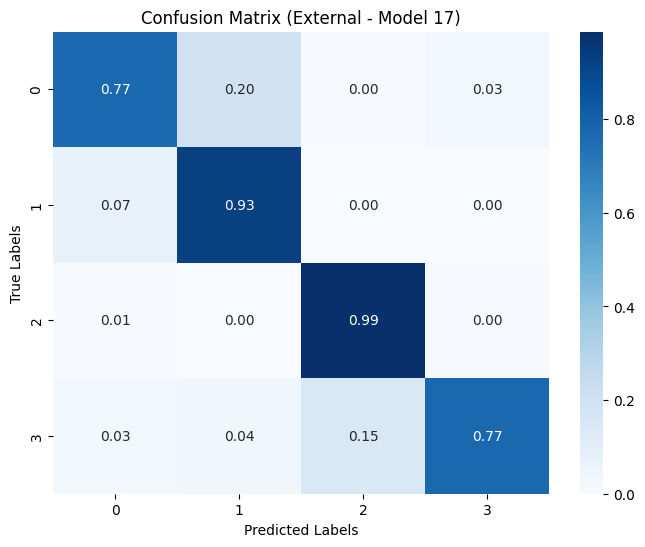

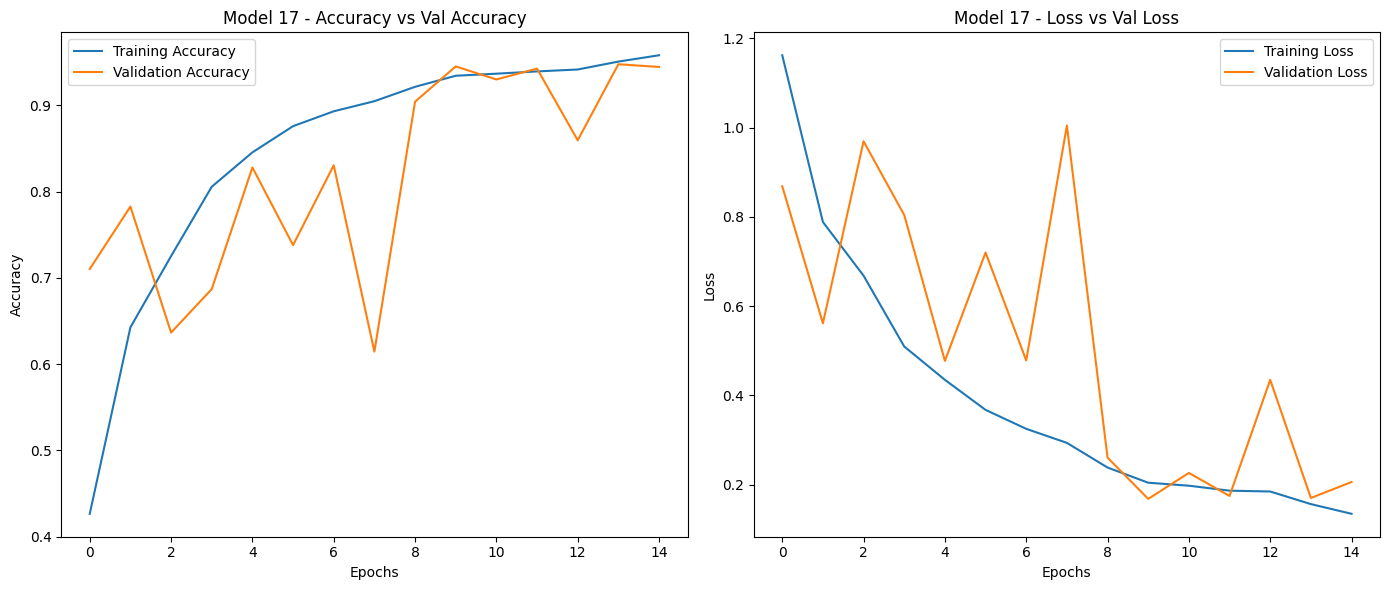


Model 17 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 18/20

Model 18 Hyperparameters:
  f_units: 32
  p_size: 2
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.35
  dense_units_2: 64
  dropout_2: 0.35
  learning_rate: 0.00390709840038868
  weight_decay: 0.007734451457037263
  batch_size: 32

=== Evaluating Model 18 ===

[== Evaluation on Test - Model 18 Data ==]
Test - Model 18 Loss: 0.1916
Test - Model 18 Accuracy: 0.9585

Classification Report (Test - Model 18 Data):
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       112
           1       0.94      0.91      0.93       115
           2       0.98      0.99      0.98       189
           3       0.99      0.95      0.97       114

    accuracy                           0.96       530
   macro avg       0.96      0.95      0.95       530
weighted avg       0.96      0.96   

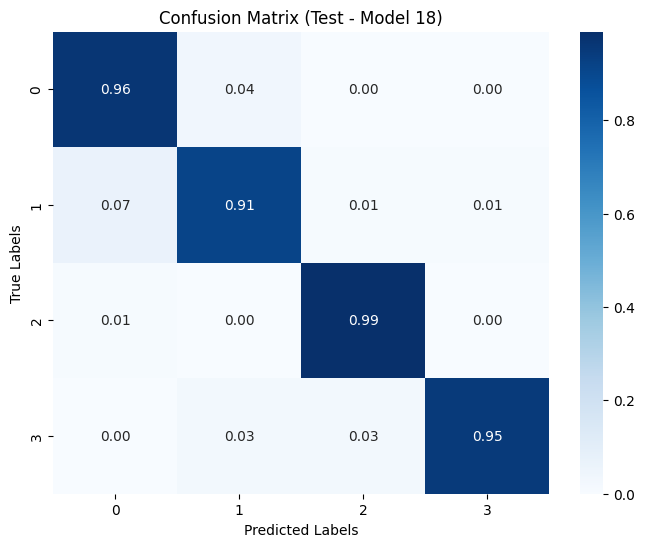


[== Evaluation on External - Model 18 Data ==]
External - Model 18 Loss: 1.0107
External - Model 18 Accuracy: 0.7910

Classification Report (External - Model 18 Data):
              precision    recall  f1-score   support

           0       0.69      0.74      0.72      1008
           1       0.25      0.96      0.39       229
           2       0.27      0.99      0.42       456
           3       1.00      0.78      0.88      9141

    accuracy                           0.79     10834
   macro avg       0.55      0.87      0.60     10834
weighted avg       0.92      0.79      0.83     10834

External - Model 18 AUC: 0.9632


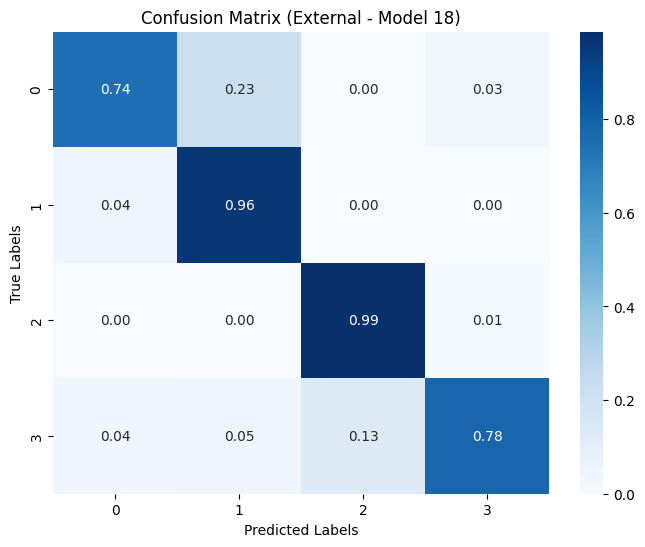

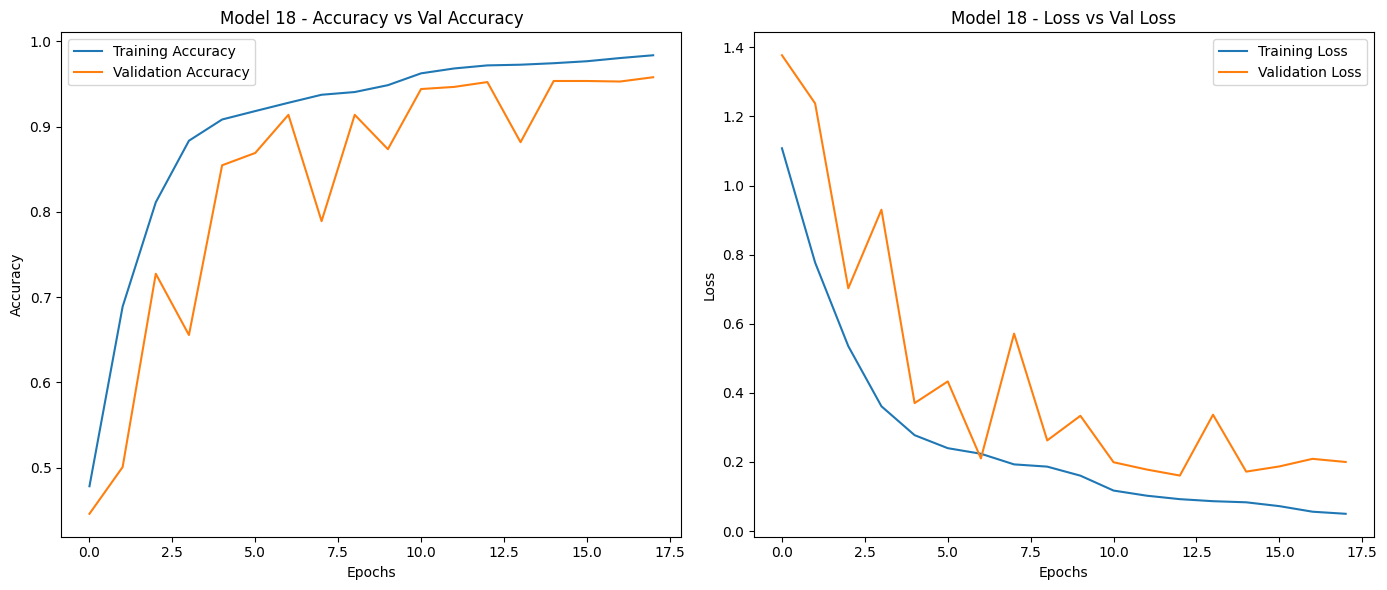


Model 18 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 19/20

Model 19 Hyperparameters:
  f_units: 32
  p_size: 3
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.3
  dense_units_2: 64
  dropout_2: 0.3
  learning_rate: 0.004050193504088638
  weight_decay: 0.008956854164429071
  batch_size: 32

=== Evaluating Model 19 ===

[== Evaluation on Test - Model 19 Data ==]
Test - Model 19 Loss: 0.1850
Test - Model 19 Accuracy: 0.9472

Classification Report (Test - Model 19 Data):
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       112
           1       0.93      0.90      0.91       115
           2       0.95      1.00      0.98       189
           3       0.99      0.91      0.95       114

    accuracy                           0.95       530
   macro avg       0.95      0.94      0.94       530
weighted avg       0.95      0.95    

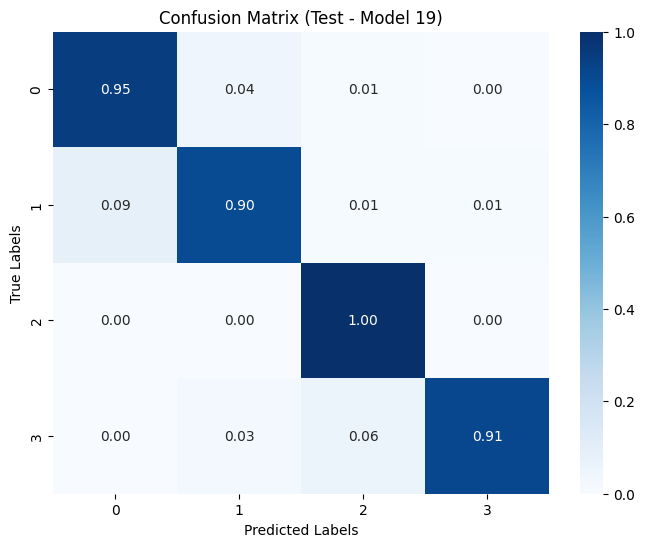


[== Evaluation on External - Model 19 Data ==]
External - Model 19 Loss: 1.4747
External - Model 19 Accuracy: 0.7974

Classification Report (External - Model 19 Data):
              precision    recall  f1-score   support

           0       0.82      0.76      0.79      1008
           1       0.27      0.96      0.43       229
           2       0.25      0.99      0.39       456
           3       0.99      0.79      0.88      9141

    accuracy                           0.80     10834
   macro avg       0.58      0.88      0.62     10834
weighted avg       0.93      0.80      0.84     10834

External - Model 19 AUC: 0.9563


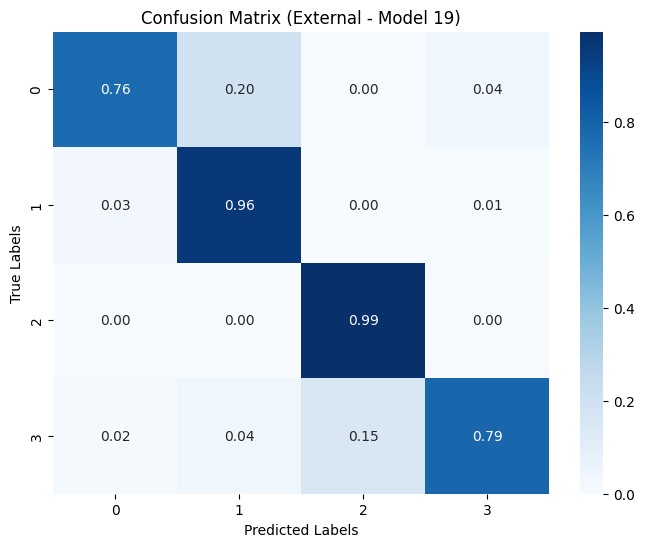

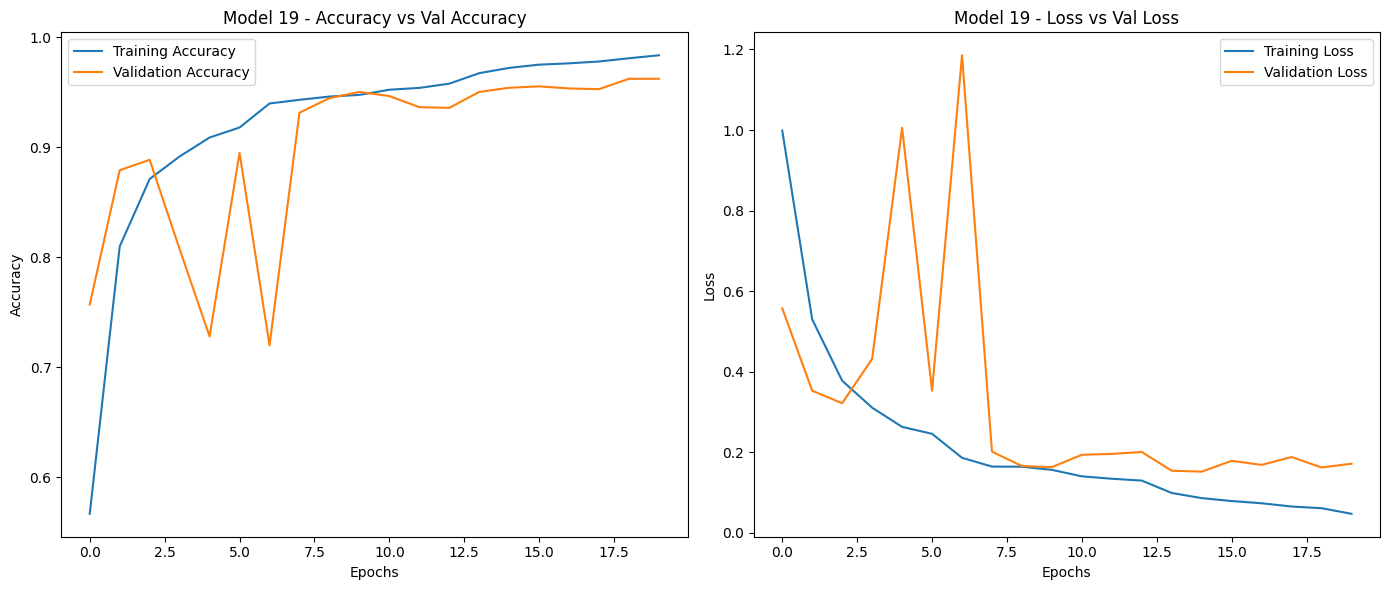


Model 19 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 20/20

Model 20 Hyperparameters:
  f_units: 32
  p_size: 2
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.35
  dense_units_2: 64
  dropout_2: 0.35
  learning_rate: 0.004106417575398697
  weight_decay: 0.006095551523196377
  batch_size: 32

=== Evaluating Model 20 ===

[== Evaluation on Test - Model 20 Data ==]
Test - Model 20 Loss: 0.1611
Test - Model 20 Accuracy: 0.9509

Classification Report (Test - Model 20 Data):
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       112
           1       0.96      0.88      0.92       115
           2       0.96      0.99      0.98       189
           3       0.99      0.93      0.96       114

    accuracy                           0.95       530
   macro avg       0.95      0.94      0.95       530
weighted avg       0.95      0.95  

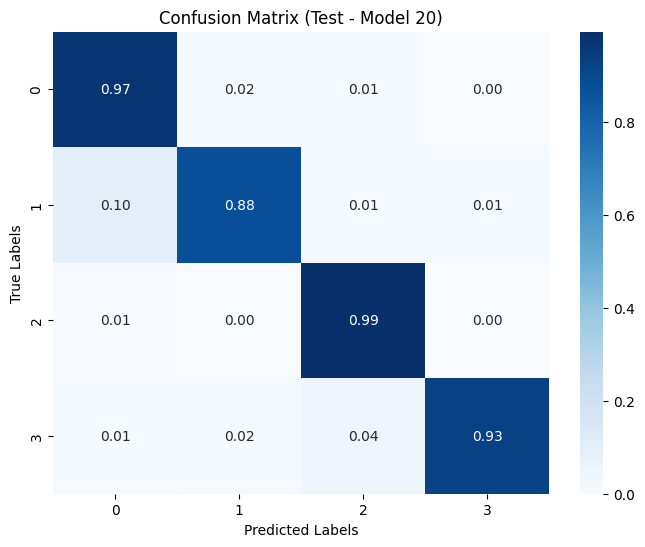


[== Evaluation on External - Model 20 Data ==]
External - Model 20 Loss: 1.5406
External - Model 20 Accuracy: 0.6448

Classification Report (External - Model 20 Data):
              precision    recall  f1-score   support

           0       0.30      0.85      0.44      1008
           1       0.33      0.80      0.46       229
           2       0.24      0.99      0.39       456
           3       1.00      0.60      0.75      9141

    accuracy                           0.64     10834
   macro avg       0.47      0.81      0.51     10834
weighted avg       0.89      0.64      0.70     10834

External - Model 20 AUC: 0.9386


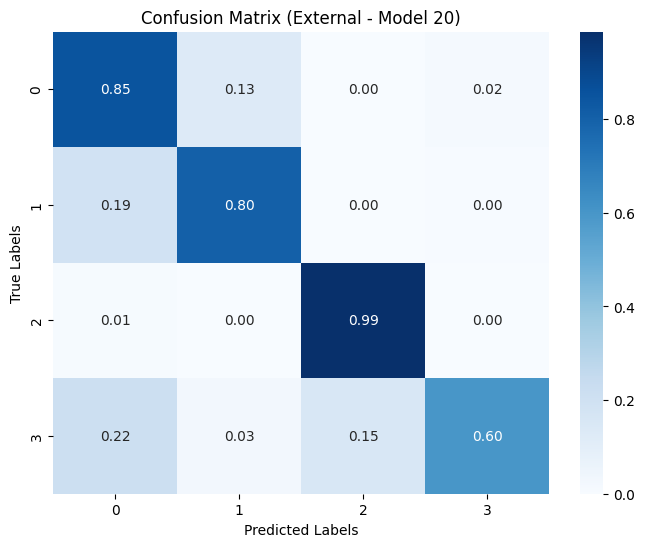

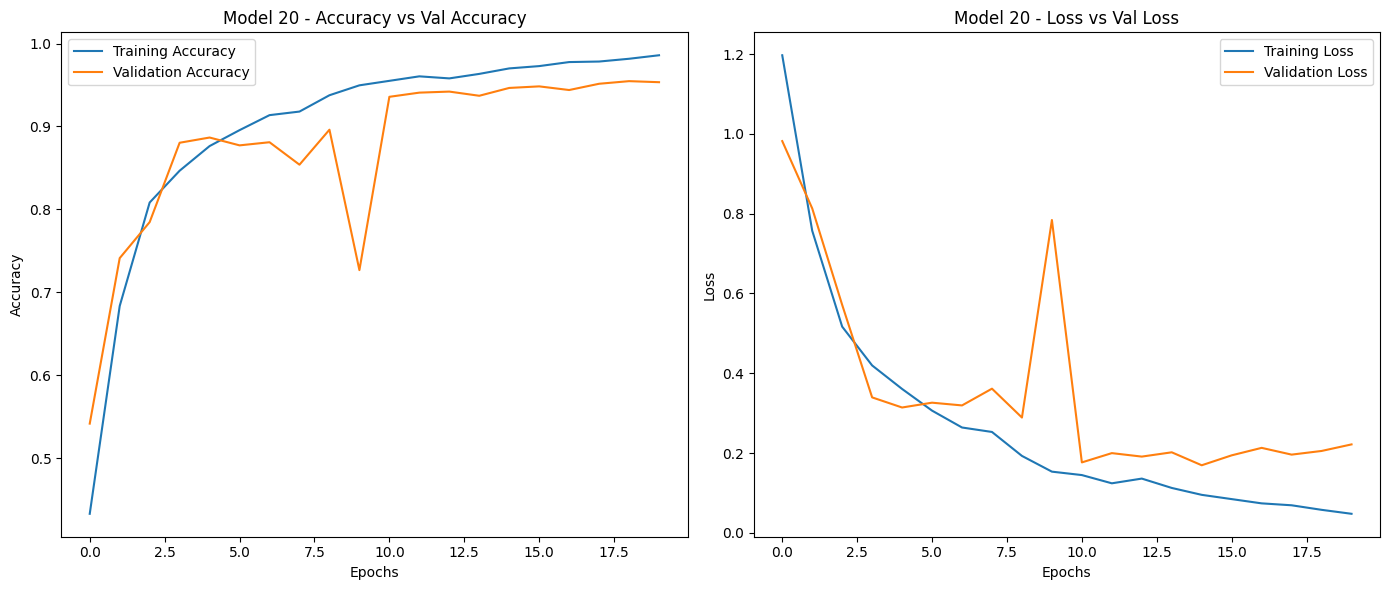


Model 20 evaluation and plotting completed!

PHASE 2 COMPLETED: 20 MODELS EVALUATED AND PLOTTED


In [4]:
import pickle
results_dir = c.RDIR / f"RES_{c.INPUT_SIZE}_{c.FILTERS}"
results_dir.mkdir(parents=True, exist_ok=True)

all_model_results = []
print("Loading individual model results...")

for model_idx in range(c.NUM_MODELS):
    individual_model_file = results_dir / f"model_{model_idx + 1}.pkl"
    
    if individual_model_file.exists():
        with open(individual_model_file, "rb") as f:
            model_result = pickle.load(f)
            all_model_results.append(model_result)
            print(f"✅ Loaded Model {model_idx + 1} results from {individual_model_file}")
    else:
        print(f"❌ Model {model_idx + 1} results not found at {individual_model_file}")

print(f"Total models loaded: {len(all_model_results)}")


dataset_loader_external = ds_loader.DatasetLoader(xlsx_path="../Data/External_Dataset/Label_Map.xlsx",data_dir="../Data/External_Dataset")
X_test_external, y_test_external = dataset_loader_external.load_data()
X_test_external, X_test = min_max_normalize(X_test_external, X_test)
print(f"External dataset loaded: {X_test_external.shape[0]} samples")

def evaluate_model(model, X, y, label="Test"):
    print(f"\n[== Evaluation on {label} Data ==]")

    loss, accuracy = model.evaluate(X, y, batch_size=32, verbose=0)
    print(f"{label} Loss: {loss:.4f}")
    print(f"{label} Accuracy: {accuracy:.4f}")

    y_pred_probs = model.predict(X, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    print(f"\nClassification Report ({label} Data):")
    print(sklearn.metrics.classification_report(y, y_pred))

    try:
        auc = sklearn.metrics.roc_auc_score(y, y_pred_probs, multi_class='ovr')
        print(f"{label} AUC: {auc:.4f}")
    except Exception as e:
        print(f"AUC could not be calculated: {e}")

    plot_confusion_matrix(y, y_pred, label)
    
    return accuracy, loss

def plot_confusion_matrix(y_true, y_pred, label="Test"):
    cm = sklearn.metrics.confusion_matrix(y_true, y_pred, normalize='true')
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=np.unique(y_true),
                yticklabels=np.unique(y_true))
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(f'Confusion Matrix ({label})')
    plt.show()

# Loop through all models for evaluation and plotting
for model_idx in range(c.NUM_MODELS):
    print(f"\n{'='*60}")
    print(f"EVALUATING AND PLOTTING MODEL {model_idx + 1}/{c.NUM_MODELS}")
    print(f"{'='*60}")
    
    cv_model = tf.keras.models.load_model(f"{c.CVDIR}_model_{model_idx + 1}.keras")
    
    model_result = all_model_results[model_idx]
    
    print(f"\nModel {model_idx + 1} Hyperparameters:")
    for param_name, param_value in model_result['hyperparameters'].items():
        print(f"  {param_name}: {param_value}")

    
    print(f"\n=== Evaluating Model {model_idx + 1} ===")
    test_acc, test_loss = evaluate_model(cv_model, X_test, y_test, f"Test - Model {model_idx + 1}")
    external_acc, external_loss = evaluate_model(cv_model, X_test_external, y_test_external, f"External - Model {model_idx + 1}")
    
    model_result.update({
        'test_accuracy': test_acc,
        'test_loss': test_loss,
        'external_accuracy': external_acc,
        'external_loss': external_loss
    })
     
    
    
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    ax[0].plot(model_result['history'].history['accuracy'], label='Training Accuracy')
    ax[0].plot(model_result['history'].history['val_accuracy'], label='Validation Accuracy')
    ax[0].set_title(f'Model {model_idx + 1} - Accuracy vs Val Accuracy')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Accuracy')
    ax[0].legend()

    ax[1].plot(model_result['history'].history['loss'], label='Training Loss')
    ax[1].plot(model_result['history'].history['val_loss'], label='Validation Loss')
    ax[1].set_title(f'Model {model_idx + 1} - Loss vs Val Loss')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Loss')
    ax[1].legend()

    plt.tight_layout()
    plt.show()
    
    print(f"\nModel {model_idx + 1} evaluation and plotting completed!")

print(f"\n{'='*80}")
print(f"PHASE 2 COMPLETED: {c.NUM_MODELS} MODELS EVALUATED AND PLOTTED")
print(f"{'='*80}")